# CRIM Intervals

## Report on Daser's Ecce nunc benedicite and two Imitation Masses based on it



In [1]:
# python imports
from crim_intervals import * 
from crim_intervals import importScore 
from crim_intervals import main_objs
from community import community_louvain
from copy import deepcopy
from IPython.display import SVG
# from ipywidgets import interact
import altair as alt
import glob as glob
import crim_intervals
import crim_intervals.visualizations as viz
import numpy as np
import os
import pandas as pd
import re
import networkx as nx
import requests

MYDIR = ("saved_csv")
CHECK_FOLDER = os.path.isdir(MYDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MYDIR)
    print("created folder : ", MYDIR)

else:
    print(MYDIR, "folder already exists.")
    
MUSDIR = ("Music_Files")
CHECK_FOLDER = os.path.isdir(MUSDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MUSDIR)
    print("created folder : ", MUSDIR)

else:
    print(MUSDIR, "folder already exists.")
    

saved_csv folder already exists.
Music_Files folder already exists.


In [2]:
alt.renderers.enable('jupyterlab')
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"


### An Additional Function Needed for Networks

In [3]:
# Adding Louvain Communities
def add_communities(G):
    G = deepcopy(G)
    partition = community_louvain.best_partition(G)
    nx.set_node_attributes(G, partition, "group")
    return G

### List of Files from Music_Files here on Jupyter Lab

In [4]:
file_list = glob.glob('Music_Files/*0001*')
file_list = sorted(file_list)
file_list

model = importScore(file_list[3])

### Getting the Entry Ngrams

In [5]:
n=3
combineUnisons=False
kind='d'
thematic = True
anywhere = False

# find entries for model
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])

mod_entry_ngrams = mod_entry_ngrams.fillna('')
# mod_entry_ngrams

### Functions to Search for Ngrams with Interact

In [6]:
def convertTuple(tup):
    out = ""
    if isinstance(tup, tuple):
        out = ', '.join(tup)
    return out

# def get_ngrams(search_pattern="", kind=["d", "q", "c", "z"], unisons=[False, True], compound=[True, False], length=[2, 3, 4, 5, 6], endpoint=["first", "last"]):
#     nr = piece.notes(combineUnisons=unisons)
#     ngrams = piece.ngrams(df=piece.melodic(df=nr, kind=kind), n=length, offsets=endpoint).fillna('')
#     ngrams = ngrams.map(convertTuple)
    
#     regex_pattern = r"^(?:[-+]?\d+(?:,\s*[-+]?\d+)*)$"
    
#     # Ensure the mask aligns with the indices of ngrams
#     mask = ngrams.reset_index(drop=True).apply(lambda x: str(x).strip() == search_pattern.strip() if isinstance(x, str) else False)
    
#     filtered_ngrams = ngrams.loc[mask].copy()
#     filtered_ngrams.astype(str).copy
    
#     beats_measures_mel = piece.detailIndex(filtered_ngrams, offset=False)

#     return beats_measures_mel.fillna("").map(str).style.map(lambda x: "background: #ccebc5" if re.search(regex_pattern, x) else "")

# @interact will fail unless installed
# @interact
# def get_ngrams(search_pattern="", kind=["d", "q", "c", "z"], unisons=[False, True], compound=[True, False], length=[2, 3, 4, 5, 6], endpoint=["first", "last"]):
#     nr = piece.notes(combineUnisons=unisons)
#     ngrams = piece.ngrams(df=piece.melodic(df=nr, kind=kind), n=length, offsets=endpoint)
#     ngrams = ngrams.map(convertTuple)

#     regex_pattern = r"^(?:[-+]?\d+(?:,\s*[-+]?\d+)*)$"

#     # mask = ngrams.reset_index(drop=True).apply(lambda x: str(x).strip() == regex_pattern.strip() if isinstance(x, str) else False)

    
#     mask = ngrams.apply(lambda x: x.apply(str).str.contains(search_pattern).any(), axis=1)

#     filtered_ngrams = ngrams[mask].copy()
#     filtered_ngrams.astype(str).copy
    
#     beats_measures_mel = piece.detailIndex(filtered_ngrams, offset=True)

#     return beats_measures_mel.fillna("-").map(str).style.map(lambda x: "background: #ccebc5" if re.search(regex_pattern, x) else "")



## Model Finder:  Comparison of Ngrams across pieces

Here we will compare the ngrams of the model with each of the Mass movements.

This shows the % of ngrams shared between the pieces, first in tabular form and then as a color chart.



In [7]:
# the model.  in the list above this is piece #5
mod_corp = CorpusBase([file_list[1]])

# # the mass movements  in the list above these are all pieces EXCEPT #5
# mass_corp = CorpusBase(file_list[:5] + file_list[6:])

mass_corp = CorpusBase(file_list[:5])

# run the comparison, passing in both sets as parameters:
# be sure to set the N for length of ngrams!
soggetto_cross_plot_narrow = mod_corp.modelFinder(n=3,
                                                  masses=mass_corp, models=mod_corp,
                                                 anywhere=False,
                                                 thematic=True)

# view the result
soggetto_cross_plot_narrow

Model,CRIM_Mass_0001_2
Mass,
CRIM_Mass_0001_1,0.777778
CRIM_Mass_0001_2,1.0
CRIM_Mass_0001_3,0.652174
CRIM_Mass_0001_4,0.305556
CRIM_Mass_0001_5,0.307692


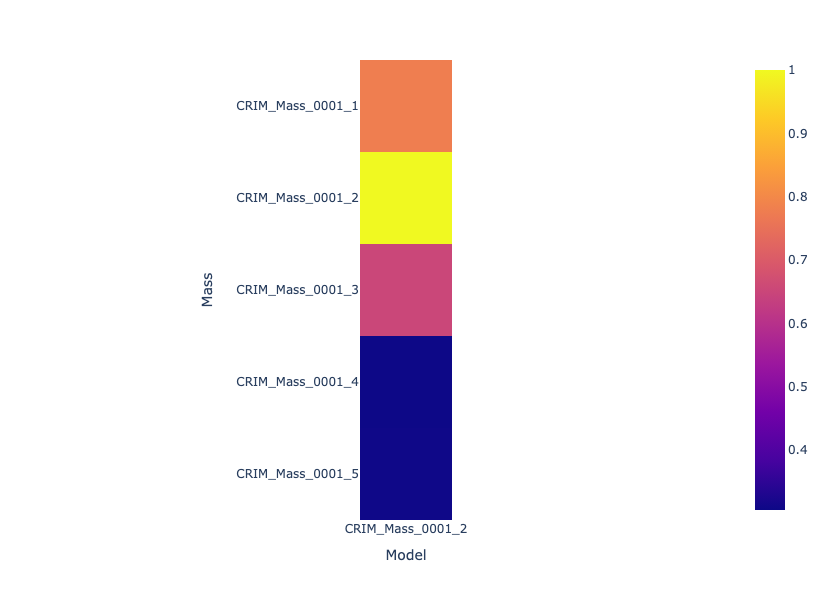

In [8]:
fig = px.imshow(soggetto_cross_plot_narrow, width=800, height=600)
fig.show()


## Conclusions from Melodic Ngrams

It seems from the above that in the case of the Kyrie, Gloria, and Credo movements, the melodic motives of Daser's Mass are more closely related to the motet those of Lasso's Mass.  On the other hand, Lasso's Sanctus and Agnus are more closely related to the motet than the corresponding movements of Daser's Mass.

Does this correspond to what human analysts notice about these movements?



# Cross Plots of ALL Movements

Here we compare all movements in the corpus to each other.

This shows which of the Mass movements are related to each other, too.  Again first in tabular then graphical form.

In [13]:

# Full Cross Plot of All movements
corpus = CorpusBase(file_list)
soggetto_cross_plot = corpus.modelFinder(n=4)
# soggetto_cross_plot.loc[

# selected_data = soggetto_cross_plot.iloc[:, :5].join(soggetto_cross_plot.iloc[:, -5 /
central_portion = soggetto_cross_plot.iloc[0:5, 5:10]

central_portion

Model,CRIM_Model_0001
Mass,
CRIM_Mass_0001_1,0.2
CRIM_Mass_0001_2,0.272059
CRIM_Mass_0001_3,0.386986
CRIM_Mass_0001_4,0.426752
CRIM_Mass_0001_5,0.75


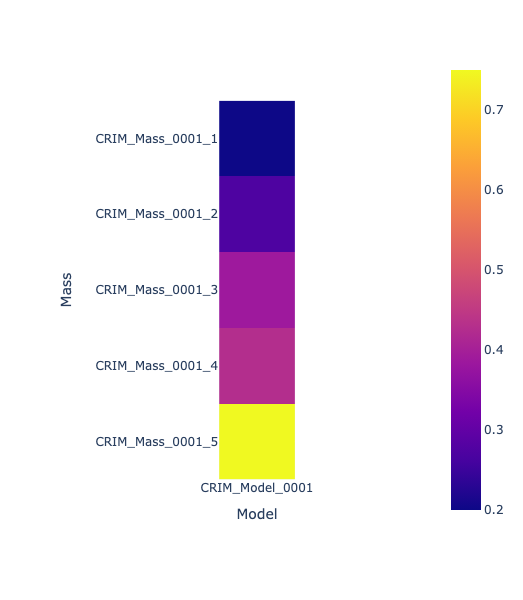

In [14]:
fig = px.imshow(central_portion, width=600, height=600)
fig.show()

## Conclusions from Melodic Ngrams of All Movements

It seems from the above that in the case of the Kyrie, Gloria, and Credo movements, the melodic motives of Daser's Mass are more closely related to the motet those of Lasso's Mass.  On the other hand, Lasso's Sanctus and Agnus are more closely related to the motet than the corresponding movements of Daser's Mass.

Does this correspond to what human analysts notice about these movements?

We might NOT be surprised to see that the Agnus movements share 60% of the ngrams (they are short movements after all).  But it IS suprising to see that the Gloria and Credo movements share over 70% of their ngrams, despite the fact that these are quite long, and despite the fact that Lasso's Gloria and Credo share only about 25% of their ngrams with the model.  This suggests, in brief, that Lasso's Gloria and Credo are very connected with the corresponding movements of Daser's Mass.



## Heat Map view of the Model, with all entries

Now let's see *where* the connections appear.  We do this with heat maps of ngrams.

First let's get the model from the list of files.  It's number "5" in our list.

In [15]:
# first, specify the model
model_url = file_list[5]
model = importScore(model_url)
model.metadata

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}

### Now Set the Type and Length of Ngrams, and Show the Results

Here are the settings we will use for the type and length of ngram:

```python
n=3
combineUnisons=False
kind='d'
thematic = False
anywhere = True
```

In [16]:
n=3
combineUnisons=False
kind='d'
thematic = False
anywhere = True


{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


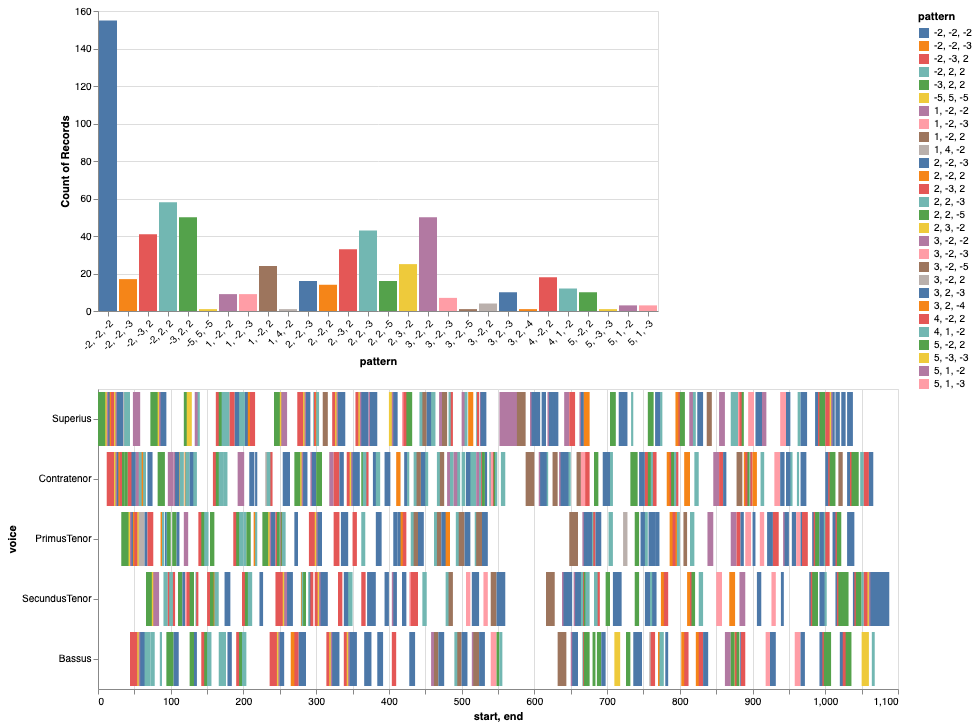

In [17]:


# find entries for model
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])
mod_mel_ngrams_duration = model.durations(df=mel, n=n, mask_df=mod_entry_ngrams)
mod_entries_stack = list(mod_entry_ngrams.stack().unique())

print(model.metadata)

display(viz.plot_ngrams_heatmap(mod_entry_ngrams, mod_mel_ngrams_duration, 
                        selected_patterns=mod_entries_stack,
                        voices=[],
                        includeCount=True))

### Now let's make sure we identify the Model and Mass files correctly

```python
model = importScore(file_list[5])
model.metadata


massfiles = file_list[:5] + file_list[6:]
massfiles
```

## Heat Map of Entries:  Model Paired with Each Mass Movement

Showing only the 'shared' entries in each pair

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


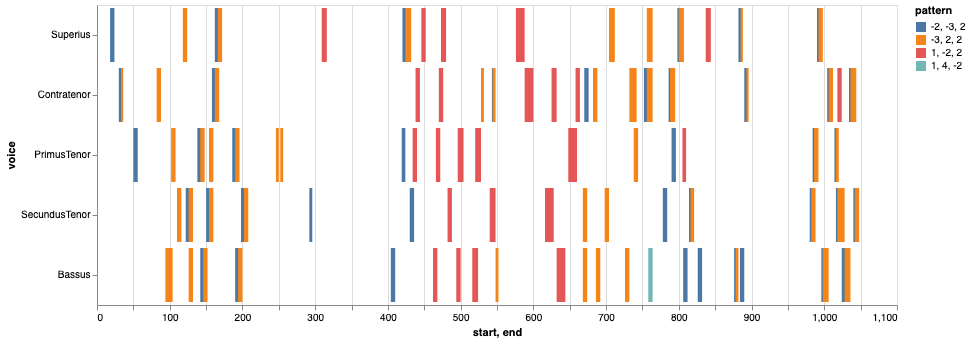

{'title': 'Missa Confitemini: Kyrie', 'composer': 'Pierre Colin', 'date': 1556}


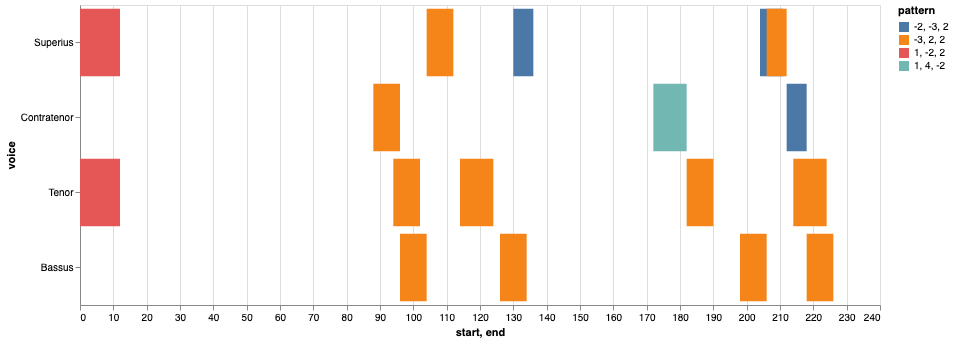

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


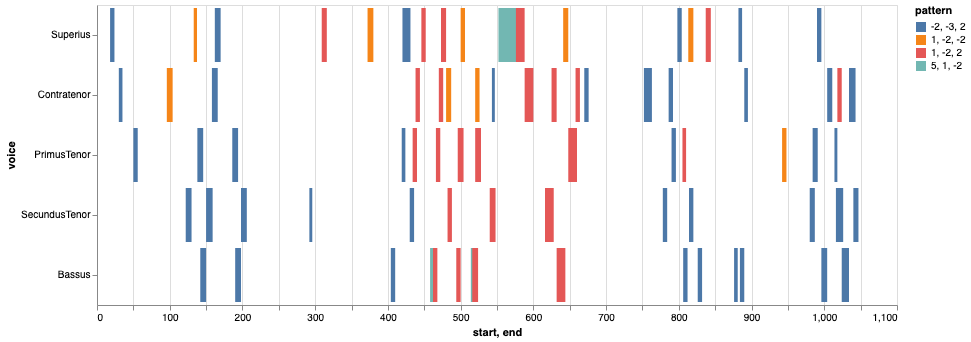

{'title': 'Missa Confitemini: Gloria', 'composer': 'Pierre Colin', 'date': 1556}


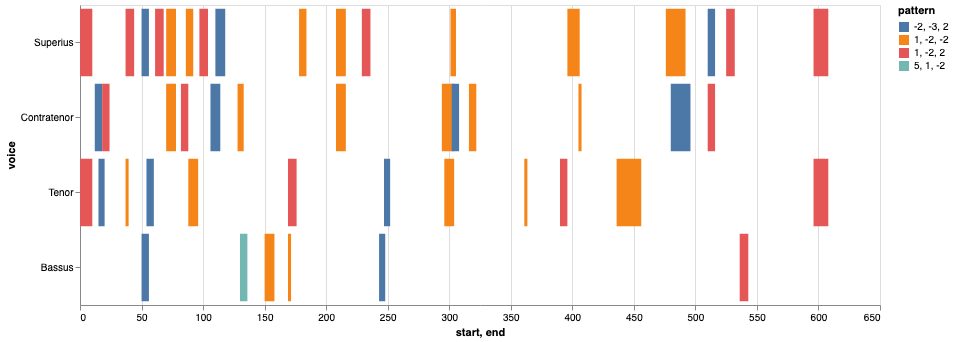

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


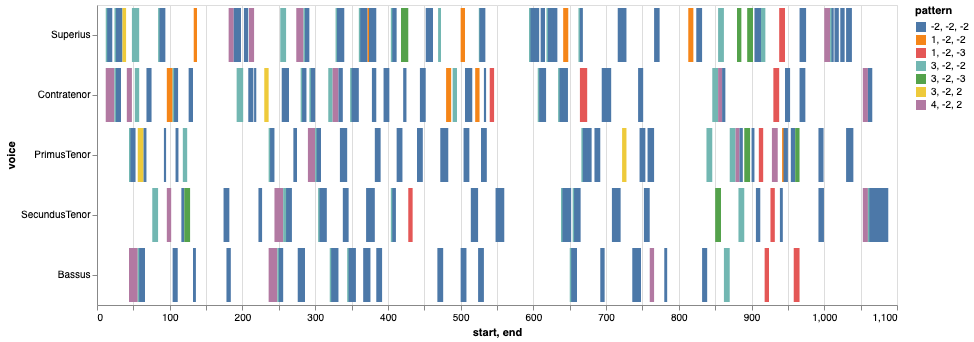

{'title': 'Missa Confitemini: Credo', 'composer': 'Pierre Colin', 'date': 1556}


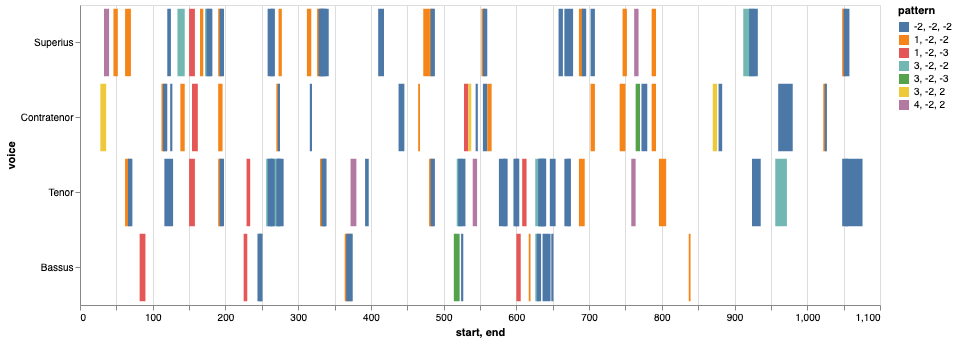

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


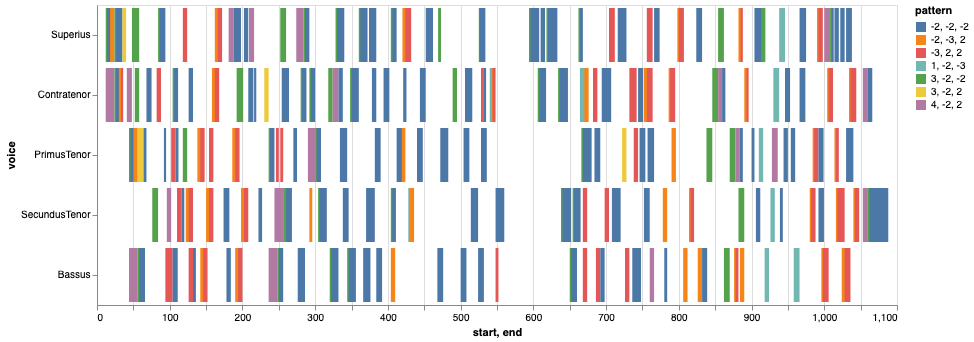

{'title': 'Missa Confitemini: Sanctus', 'composer': 'Pierre Colin', 'date': 1556}


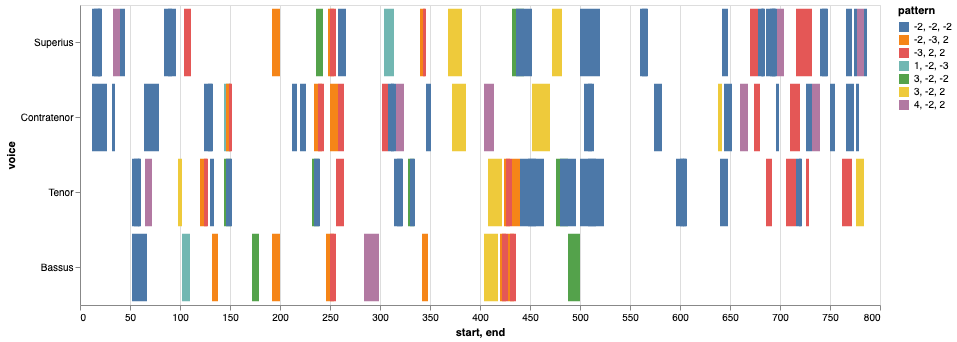

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


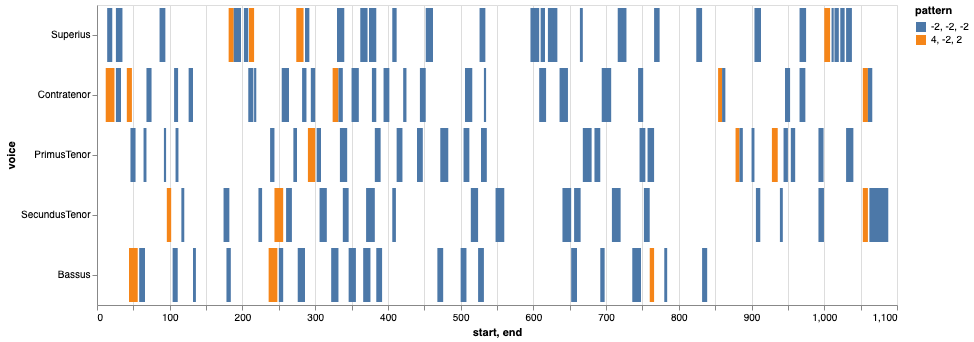

{'title': 'Missa Confitemini: Agnus Dei', 'composer': 'Pierre Colin', 'date': 1556}


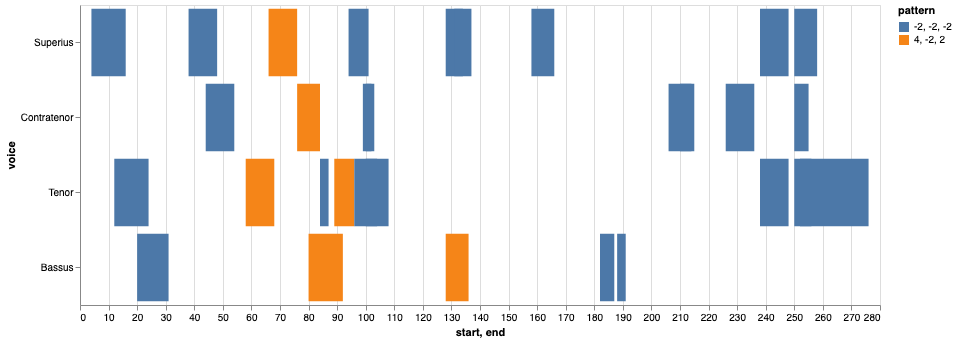

In [18]:

# find entries for model

model = importScore(file_list[5])
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])
mod_mel_ngrams_duration = model.durations(df=mel, n=n, mask_df=mod_entry_ngrams)
mod_entries_stack = list(mod_entry_ngrams.stack().unique())

# find entries mass movements:
mass_movements = file_list[:5] + file_list[6:]
for movement in mass_movements:       
    m_movement = importScore(movement)
    nr = m_movement.notes(combineUnisons=combineUnisons)
    mel = m_movement.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
    mass_mvmt_mel_ngrams = m_movement.ngrams(df=mel, n=n)
    mass_mvmt_entries = m_movement.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere)
    mass_mvmt_mel_ngrams_duration = m_movement.durations(df=mel, n=n, mask_df=mass_mvmt_entries)
    mass_mvmt_entries_stack = mass_mvmt_entries.stack()
    
    
    # find shared entries
    shared_entries = list(set(mass_mvmt_entries_stack).intersection(mod_entries_stack))

    # or instead focus on one soggetto
    # in this case update code below, replacing 'shared_entries' with 'selected_entries'
    # selected_entries = [('-2', '3', '-2')]
    
    # print model metadata and chart
    print(model.metadata)
    # print(shared_entries)
    display(viz.plot_ngrams_heatmap(mod_entry_ngrams, mod_mel_ngrams_duration, 
                        selected_patterns=shared_entries,
                        voices=[], includeCount=False))
    
    
    # # print mass movement metadata and chart
    print(m_movement.metadata)
    display(viz.plot_ngrams_heatmap(mass_mvmt_entries, mass_mvmt_mel_ngrams_duration, 
                                selected_patterns=shared_entries,
                                voices=[], includeCount=False)) 

# Exploring Cadences

Here we can look at the cadences in a single piece, or across several of them at once.

In [33]:

file_list = glob.glob('Music_Files/*')
file_list = sorted(file_list)
corpus = CorpusBase(file_list)

#select function.  remember to omit "()"
func = ImportedPiece.cadences

#run function on each piece; be sure to include keyword arguments
list_of_dfs = corpus.batch(func = func, kwargs = {'keep_keys': True}, metadata = True)

#concatenate the resulting dataframes into one
corpus_cadences = pd.concat(list_of_dfs, ignore_index = False)

# new order for columns:
col_list = ['Composer', 'Title', 'Measure', 'Beat', 'Pattern', 'CadType', 'Tone','CVFs',
                'LeadingTones', 'Sounding', 'Low','RelLow','RelTone',
                'Progress','SinceLast','ToNext']

corpus_cadences = corpus_cadences[col_list]

# show the results
corpus_cadences.head()


mei.base: WARNING: Importing <tie> without @startid and @endid is not yet supported.


,Composer,Title,Measure,Beat,Pattern,CadType,Tone,CVFs,LeadingTones,Sounding,Low,RelLow,RelTone,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,,,
80.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,11.0,1.0,BC1,Authentic,G,CTB,1.0,4.0,G2,-P8,P8,0.285714,80.0,48.0
128.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,17.0,1.0,C1T-2,Clausula Vera,D,CT,1.0,2.0,D4,P5,P5,0.457143,48.0,12.0
140.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,18.0,3.0,C1z,Abandoned Clausula Vera,G,zC,1.0,3.0,G3,P1,P8,0.500000,12.0,12.0
152.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,20.0,1.0,C1T-2,Clausula Vera,C,CT,1.0,4.0,A3,M2,P4,0.542857,12.0,80.0
232.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,30.0,1.0,C2b,Evaded Authentic,D,CTb,1.0,4.0,B-3,m3,P5,0.828571,80.0,12.0


### Filter to Show Selected Values in Some Column

For example:

```corpus_cadences[corpus_cadences["CVFs"]  == "CTb"]```

In [34]:
corpus_cadences[corpus_cadences["CVFs"]  == "CTb"]

,Composer,Title,Measure,Beat,Pattern,CadType,Tone,CVFs,LeadingTones,Sounding,Low,RelLow,RelTone,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,,,
232.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,30.0,1.0,C2b,Evaded Authentic,D,CTb,1.0,4.0,B-3,m3,P5,0.828571,80.0,12.0
500.0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Gloria,63.0,3.0,C1b,Evaded Authentic,D,CTb,1.0,3.0,B-3,m3,P5,0.735294,52.0,16.0
416.0,Ludwig Daser,Ecce nunc benedicite,53.0,1.0,C1b,Evaded Authentic,D,CTb,1.0,4.0,G3,P1,P5,0.684211,36.0,12.0
228.0,Orlandus Lassus,Lasso Missa Ecce nunc benedicite: Kyrie,29.0,3.0,C1b,Evaded Authentic,D,CTb,1.0,4.0,B-3,m3,P5,0.814286,52.0,12.0


### A Chart of Types and Tones



/Users/rfreedma/anaconda3/envs/intervals/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



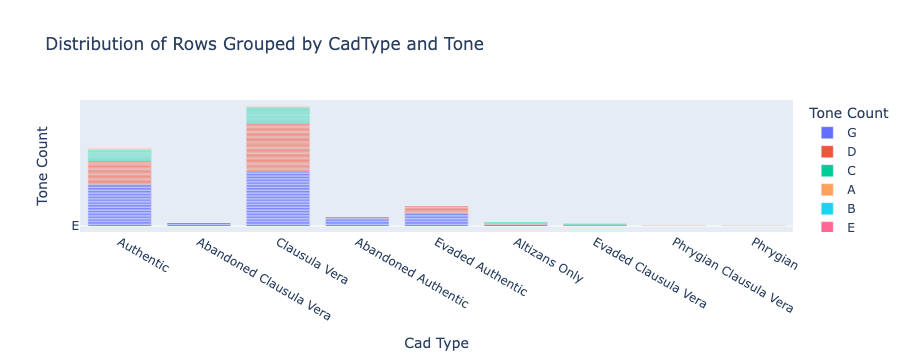

In [35]:
filtered_df = corpus_cadences[['CadType', 'Tone']]

# Create the bar chart
fig = px.bar(filtered_df, x='CadType', y='Tone', color='Tone',
             labels={'CadType':'Cad Type', 'Tone':'Tone Count'},
             title='Distribution of Rows Grouped by CadType and Tone')

# Show the plot
fig.show()

#### Show The Cadences as a Radar Plot

If `combinedType` is `True` you will see all the cadence subtype details.
If `displayAll` is `True` you will see all possible cadence tones.

```
corpus.compareCadenceRadarPlots(
                                combinedType = True, 
                                displayAll = False, 
                                renderer = "iframe")
```

/Users/rfreedma/anaconda3/envs/intervals/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



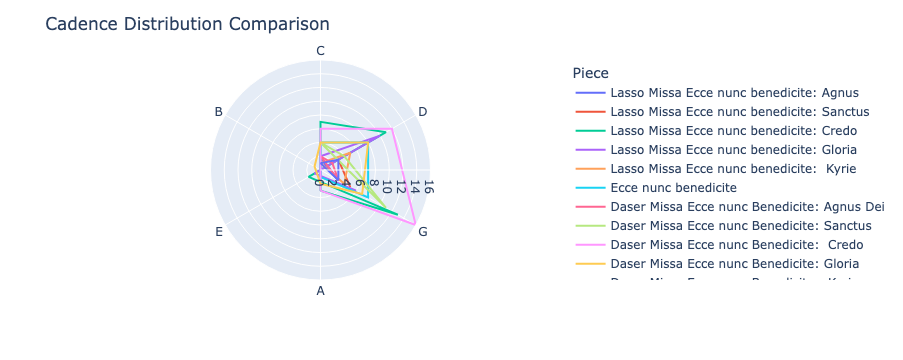

In [36]:
corpus.compareCadenceRadarPlots(
                                combinedType = False, 
                                displayAll = False, 
                                renderer = "iframe")


### Print Cadences in Verovio with Hightlights of Details

load the list of pieces from the local folder:

```python
file_list = glob.glob('Music_Files/*')
file_list = sorted(file_list)
```

In [37]:
# load the list of pieces from the local folder
file_list = glob.glob('Music_Files/*')
file_list = sorted(file_list)


### Cadences with Linked Examples for A Single Piece

Here we show the cadences plus a link to a verovio rendering with highlights.


In [38]:
piece = importScore(file_list[0])

# We also need to load the files from GIT, for the LinkExample function

prefix = 'https://raw.githubusercontent.com/RichardFreedman/CRIM_Additions/main/Daser_Missa_Ecce_nunc/MEI/'

piece = importScore(file_list[0])
url = prefix + file_list[0]

cd=piece.cadences()
piece.linkExamples(df=cd, piece_url=url)

,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
80.0,Authentic,1,CTB,G2,-P8,G,P8,4/2,11.0,1.0,4.0,0.285714,80.0,48.0
128.0,Clausula Vera,1,CT,D4,P5,D,P5,4/2,17.0,1.0,2.0,0.457143,48.0,12.0
140.0,Abandoned Clausula Vera,1,zC,G3,P1,G,P8,4/2,18.0,3.0,3.0,0.500000,12.0,12.0
152.0,Clausula Vera,1,CT,A3,M2,C,P4,4/2,20.0,1.0,4.0,0.542857,12.0,80.0
232.0,Evaded Authentic,1,CTb,B-3,m3,D,P5,4/2,30.0,1.0,4.0,0.828571,80.0,12.0
244.0,Clausula Vera,0,tACT,D3,-P4,D,P5,4/2,31.0,3.0,4.0,0.871429,12.0,20.0
264.0,Clausula Vera,1,CT,G3,P1,G,P8,4/2,34.0,1.0,3.0,0.942857,20.0,32.0


### Corpus with Annotated Scores

 Note that we can filter the results in various ways.  View the code to see how.

In [39]:
# We also need to load the files from GIT, for the LinkExample function

prefix = 'https://raw.githubusercontent.com/RichardFreedman/CRIM_Additions/main/Daser_Missa_Ecce_nunc/MEI/'

# piece_id = 'Daser_Missa_Ecce_nunc_01_E.mei'
# piece_id = 'Daser_Motette_Ecce-nunc_E.mei'
dfs = []

for path in file_list:
    piece_id = os.path.basename(path) 
    url = prefix + piece_id  
    piece = importScore(url)
    cd=piece.cadences()
    
    # filter for a given type or tone
    # cd = cd.loc[cd['CVFs'] == 'CTb']
    
    print(piece_id)
    piece.linkExamples(df=cd, piece_url=url)



Daser_Missa_Ecce_nunc_01_E.mei


,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
80.0,Authentic,1,CTB,G2,-P8,G,P8,4/2,11.0,1.0,4.0,0.285714,80.0,48.0
128.0,Clausula Vera,1,CT,D4,P5,D,P5,4/2,17.0,1.0,2.0,0.457143,48.0,12.0
140.0,Abandoned Clausula Vera,1,zC,G3,P1,G,P8,4/2,18.0,3.0,3.0,0.500000,12.0,12.0
152.0,Clausula Vera,1,CT,A3,M2,C,P4,4/2,20.0,1.0,4.0,0.542857,12.0,80.0
232.0,Evaded Authentic,1,CTb,B-3,m3,D,P5,4/2,30.0,1.0,4.0,0.828571,80.0,12.0
244.0,Clausula Vera,0,tACT,D3,-P4,D,P5,4/2,31.0,3.0,4.0,0.871429,12.0,20.0
264.0,Clausula Vera,1,CT,G3,P1,G,P8,4/2,34.0,1.0,3.0,0.942857,20.0,32.0


Daser_Missa_Ecce_nunc_02_E.mei


,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
40.0,Evaded Authentic,-1.0,cB,G3,P1,NaN,NaN,4/2,6.0,1.0,4.0,0.058824,40.0,24.0
64.0,Authentic,1.0,CuTB,D3,-P4,D,P5,4/2,9.0,1.0,4.0,0.094118,24.0,56.0
120.0,Authentic,1.0,CTB,G2,-P8,G,P8,4/2,16.0,1.0,4.0,0.176471,56.0,28.0
148.0,Clausula Vera,1.0,CT,D4,P5,D,P5,4/2,19.0,3.0,2.0,0.217647,28.0,24.0
172.0,Clausula Vera,0.0,CT,D3,-P4,D,P5,4/2,22.0,3.0,4.0,0.252941,24.0,44.0
216.0,Abandoned Authentic,1.0,Cxzx,G4,P8,G,P8,4/2,28.0,1.0,1.0,0.317647,44.0,28.0
244.0,Phrygian Clausula Vera,1.0,CT,A3,M2,A,M2,4/2,31.0,3.0,4.0,0.358824,28.0,36.0
280.0,"<a href=""https://eleon024.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fraw.githubusercontent.com%2FRichardFreedman%2FCRIM_Additions%2Fmain%2FDaser_Missa_Ecce_nunc%2FMEI%2FDaser_Missa_Ecce_nunc_02_E.mei&ema_expression=%2F34-36%2F1%2B3%2B4%2B2%2C1%2B3%2B4%2B2%2C1%2B3%2B4%2B2%2F%403.0-end%2B%403.0-end%2B%403.0-end%2B%403.0-end%2C%40all%2B%40all%2B%40all%2B%40all%2C%40start-1.0%2B%40start-1.0%2B%40start-1.0%2B%40start-1.0%2Fhighlight&measure_range=34-36&observation=+Authentic"" rel=""noopener noreferrer"" target=""_blank"">Authentic",1.0,CuTB,D3,-P4,D,P5,4/2,36.0,1.0,4.0,0.411765,36.0,40.0
320.0,Authentic,1.0,tCB,C3,-P5,C,P4,4/2,41.0,1.0,4.0,0.470588,40.0,56.0


Daser_Missa_Ecce_nunc_03_E.mei


...

,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
56.0,Authentic,1,CTB,D3,-P5,D,P4,4/2,8.0,1.0,6.0,0.046706,56.0,40.0
96.0,Authentic,1,CTB,G2,-M9,G,m7,4/2,13.0,1.0,6.0,0.080067,40.0,36.0
132.0,Evaded Clausula Vera,1,Ct,D3,-P5,D,P4,4/2,17.0,3.0,6.0,0.110092,36.0,8.0
140.0,Clausula Vera,1,CT,G3,-M2,G,m7,4/2,18.0,3.0,6.0,0.116764,8.0,8.0
148.0,Authentic,1,tCB,D3,-P5,D,P4,4/2,19.0,3.0,4.0,0.123436,8.0,12.0
160.0,Abandoned Authentic,0,Cx,B3,M2,D,P4,4/2,21.0,1.0,3.0,0.133445,12.0,44.0
204.0,Authentic,1,CuTB,D3,-P5,D,P4,4/2,26.0,3.0,5.0,0.170142,44.0,12.0
216.0,Clausula Vera,1,tCT,C3,-M6,C,m3,4/2,28.0,1.0,5.0,0.180150,12.0,12.0
228.0,Clausula Vera,1,TC,E4,P5,G,m7,4/2,29.0,3.0,4.0,0.190158,12.0,16.0


Lassus_Missa_Ecce_04.mei


,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
40.0,Authentic,1,CB,G3,P1,G,P8,4/2,6.0,1.0,5.0,0.087719,40.0,16.0
56.0,Authentic,1,CTB,D3,-P4,D,P5,4/2,8.0,1.0,6.0,0.122807,16.0,48.0
104.0,Clausula Vera,1,CTx,G3,P1,G,P8,4/2,14.0,1.0,5.0,0.228070,48.0,64.0
168.0,Authentic,1,CTB,G3,P1,G,P8,4/2,22.0,1.0,6.0,0.368421,64.0,100.0
268.0,Clausula Vera,1,TC,G3,P1,G,P8,4/2,34.0,3.0,5.0,0.587719,100.0,68.0
336.0,Clausula Vera,1,CT,D3,-P4,D,P5,4/2,43.0,1.0,2.0,0.736842,68.0,28.0
364.0,Clausula Vera,1,CT,D3,-P4,D,P5,4/2,46.0,3.0,3.0,0.798246,28.0,92.0
456.0,Clausula Vera,1,CT,G3,P1,G,P8,4/2,58.0,1.0,3.0,1.000000,92.0,8.0


Lassus_Missa_Ecce_05.mei


,CadType,LeadingTones,CVFs,Low,RelLow,Tone,RelTone,TSig,Measure,Beat,Sounding,Progress,SinceLast,ToNext
Last,,,,,,,,,,,,,,
40.0,Clausula Vera,1,CT,D3,-P4,D,P5,4/2,6.0,1.0,6,0.196078,40.0,16.0
56.0,Clausula Vera,1,CT,G3,P1,G,P8,4/2,8.0,1.0,5,0.274510,16.0,20.0
76.0,Clausula Vera,1,CT,C3,-P5,C,P4,4/2,10.0,3.0,4,0.372549,20.0,40.0
116.0,Authentic,1,tCTB,C3,-P5,C,P4,4/2,15.0,3.0,6,0.568627,40.0,40.0
156.0,Authentic,1,CTB,G3,P1,G,P8,3/1,19.0,1.0,6,0.764706,40.0,48.0
204.0,Authentic,1,CTB,G3,P1,G,P8,3/1,23.0,1.0,6,1.000000,48.0,12.0


## Groups of Cadences

In [100]:
# Convert to string if necessary
corpus_cadences['CadType'] = corpus_cadences['CadType'].astype(str)
corpus_cadences['Tone'] = corpus_cadences['Tone'].astype(str)

# Combine CadType and Tone
corpus_cadences['Combined'] = corpus_cadences['CadType'] + corpus_cadences['Tone'] + corpus_cadences['CVFs']
# corpus_cadences['Combined'] = corpus_cadences['Tone']

corpus_cadences.groupby(['Tone']).size().reset_index(name = 'counts')

,Tone,counts
0,A,10
1,B,1
2,C,33
3,D,67
4,E,3
5,G,79
6,nan,13


## Network of Cadences

In [101]:
# Step 2: Create Edges Based on CadType
edges = []
for cad_type, group in corpus_cadences.groupby('CVFs'):
    titles = group['Title'].unique()
    for i in range(len(titles)):
        for j in range(i+1, len(titles)):
            edges.append((titles[i], titles[j]))

# Step 3: Create Nodes and Edges
G = nx.Graph()

# Add nodes
G.add_nodes_from(corpus_cadences['Title'].unique())

# Add edges
G.add_edges_from(edges)

G = add_communities(G)

# Step 4: Visualize the Graph (Optional)
# nx.draw(G, with_labels=True)

# set physics
cmap = Network(notebook=True,
                   width="1000",
                          height="750",
                          bgcolor="black", 
                          font_color="white")
    # Set the physics layout of the network
cmap.set_options("""
{
"physics": {
"enabled": true,
"forceAtlas2Based": {
    "springLength": 1
},
"solver": "forceAtlas2Based"
}
}
""")

cmap.from_nx(G)
# return the network
cmap.show("final_topic_pairs.html")




### Cadence Progress Plots

Use `Music_Files/*1*.mei` for Kyrie, `Music_Files/*2*.mei` for Gloria, etc.

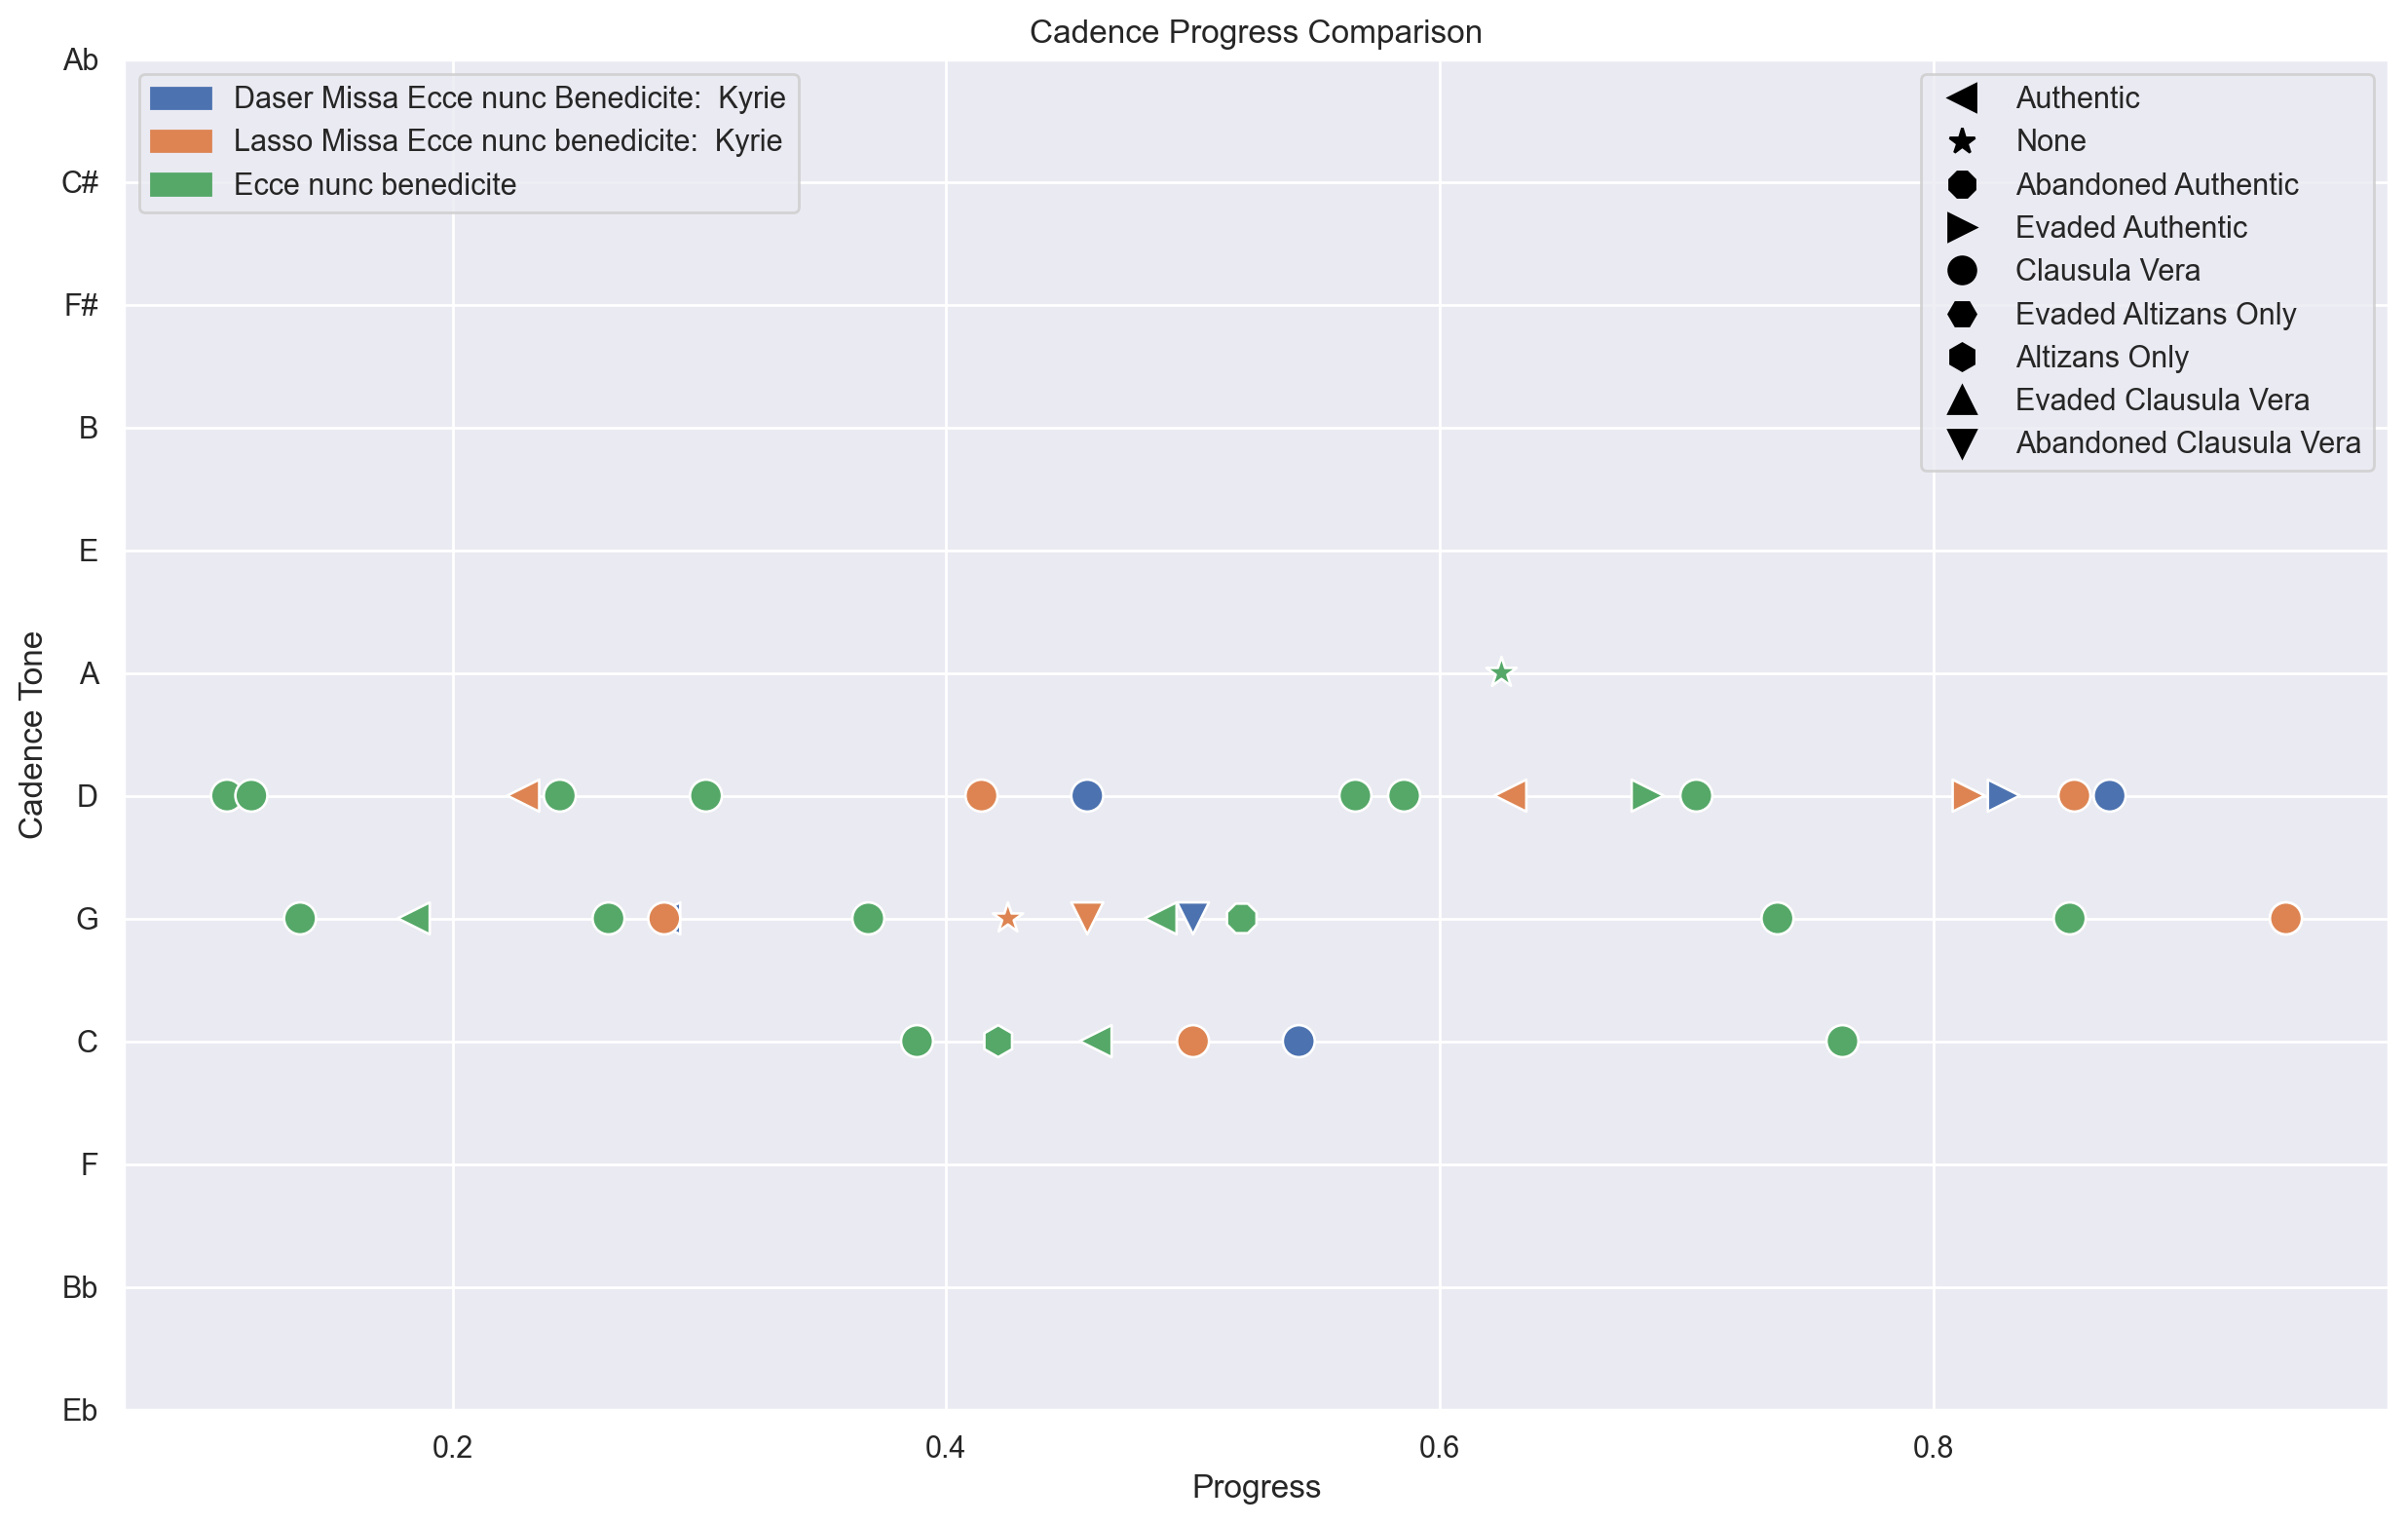

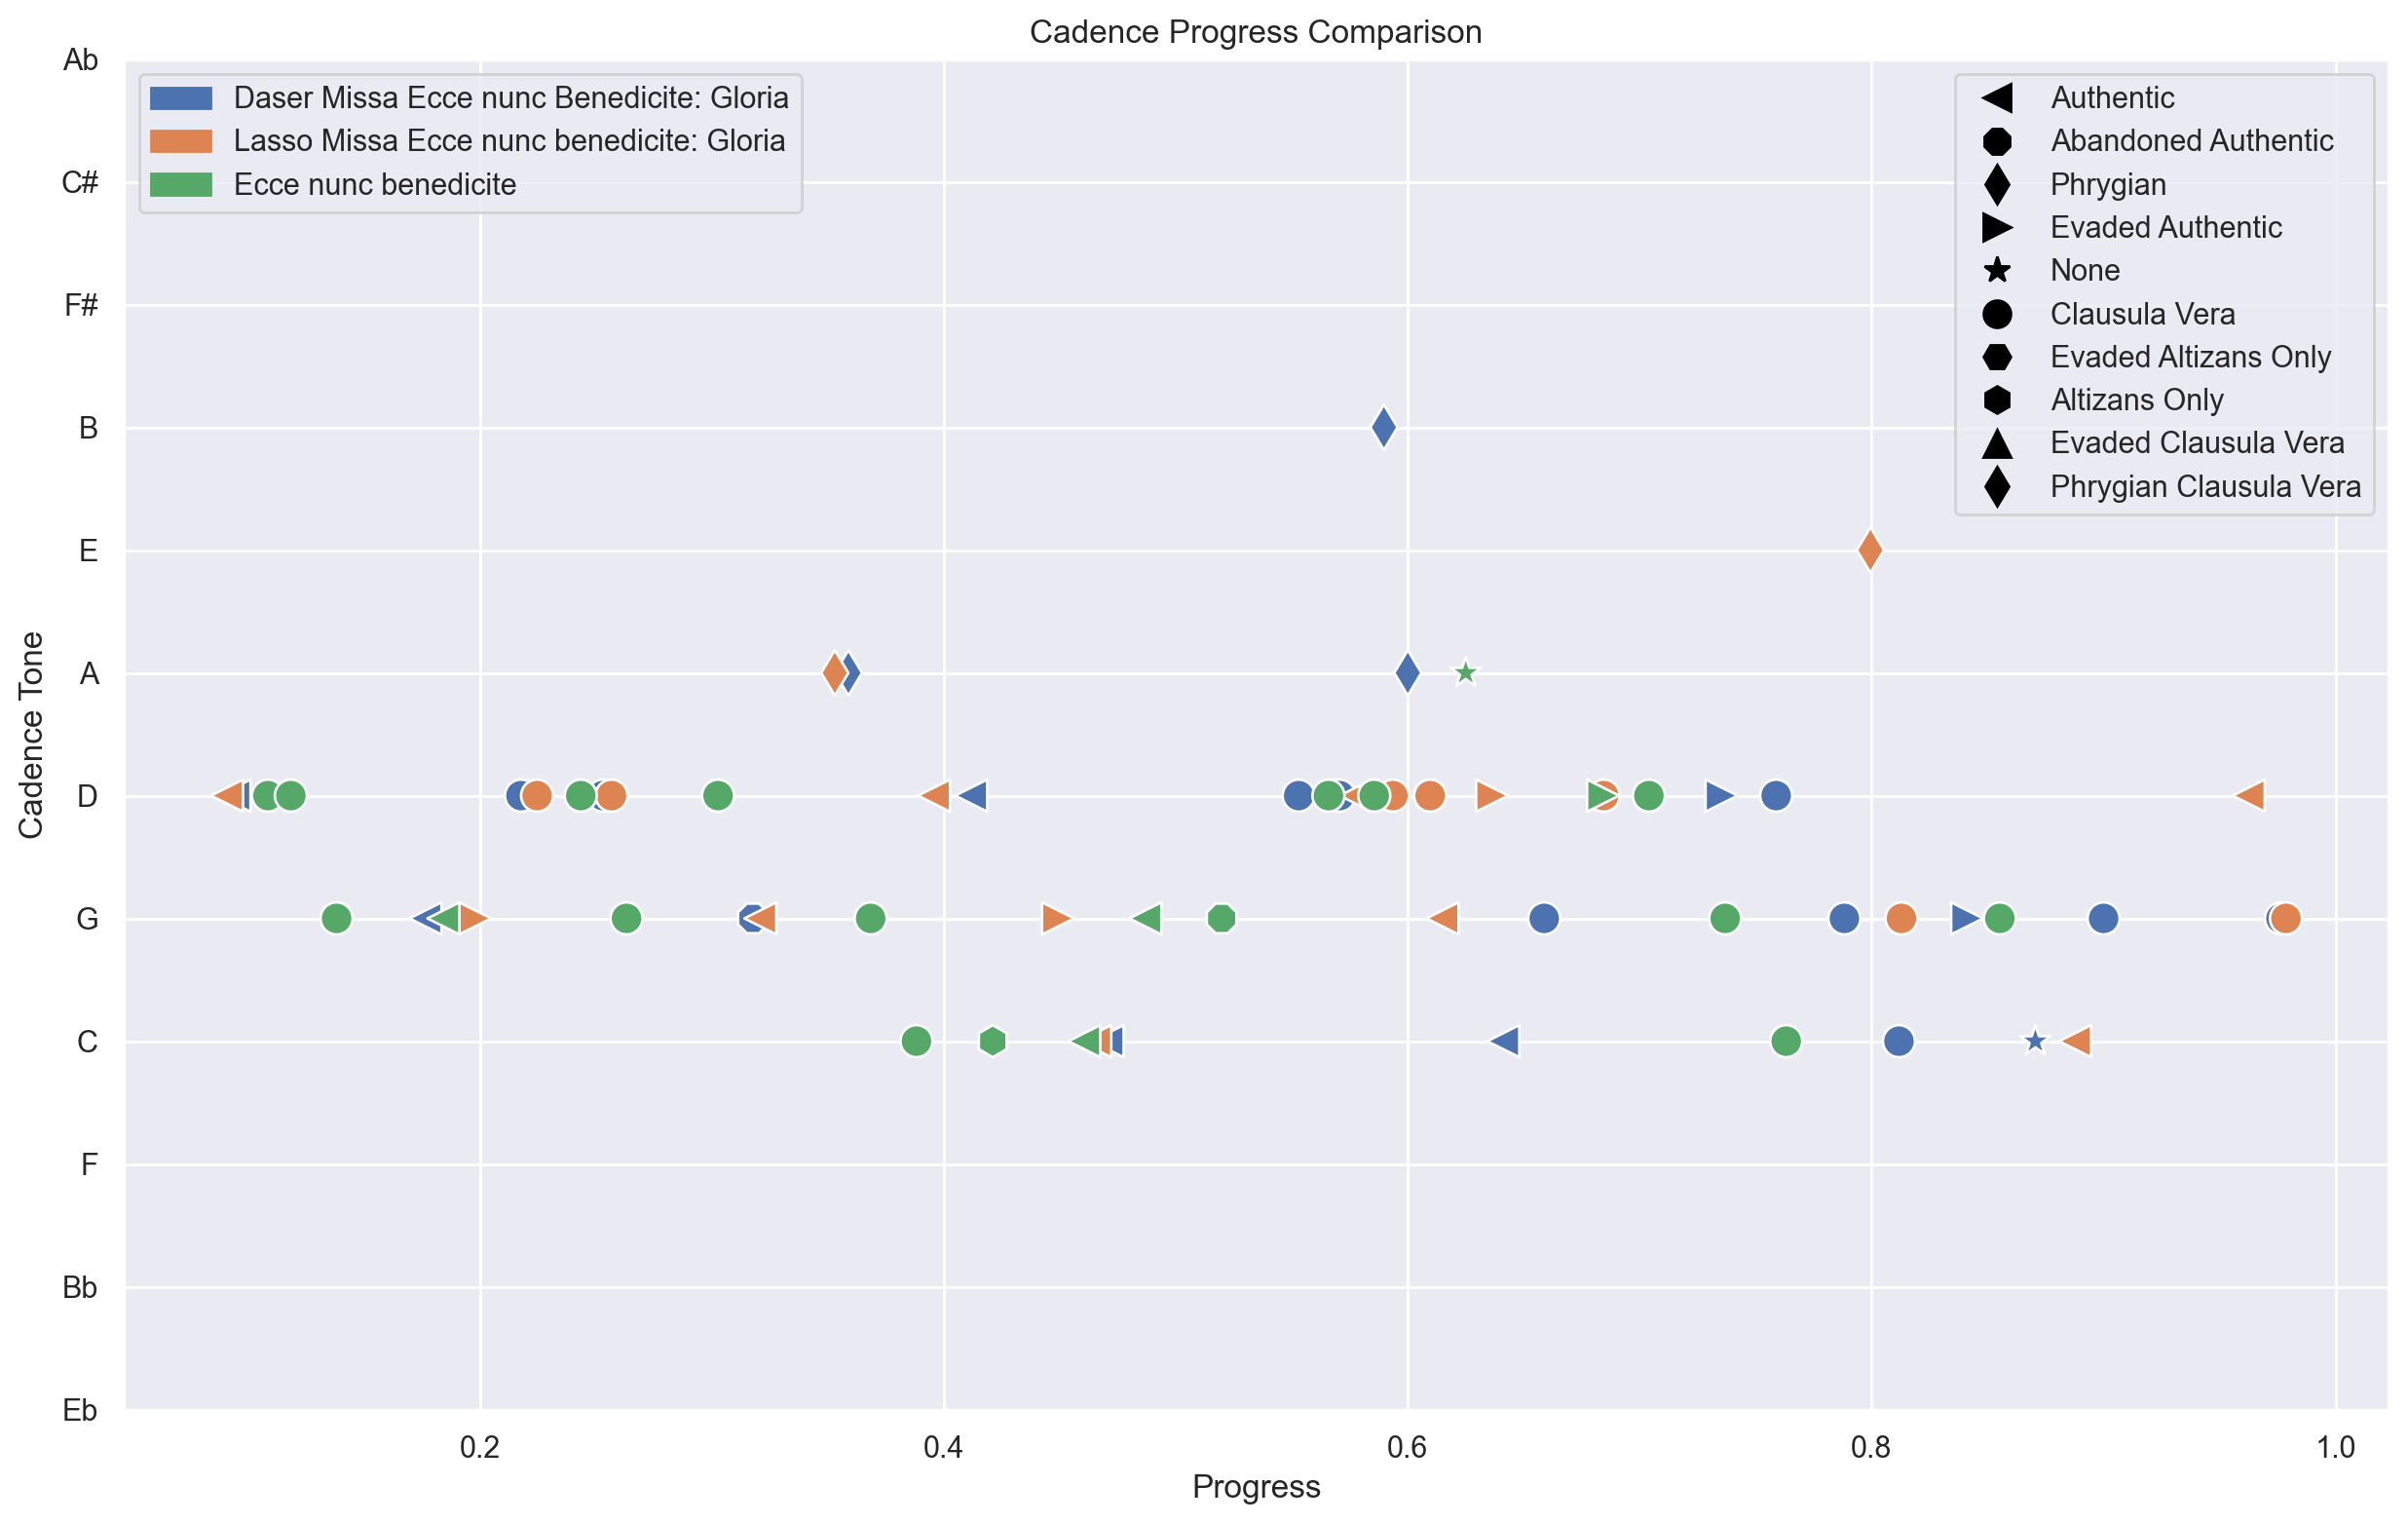

mei.base: WARNING: Importing <tie> without @startid and @endid is not yet supported.


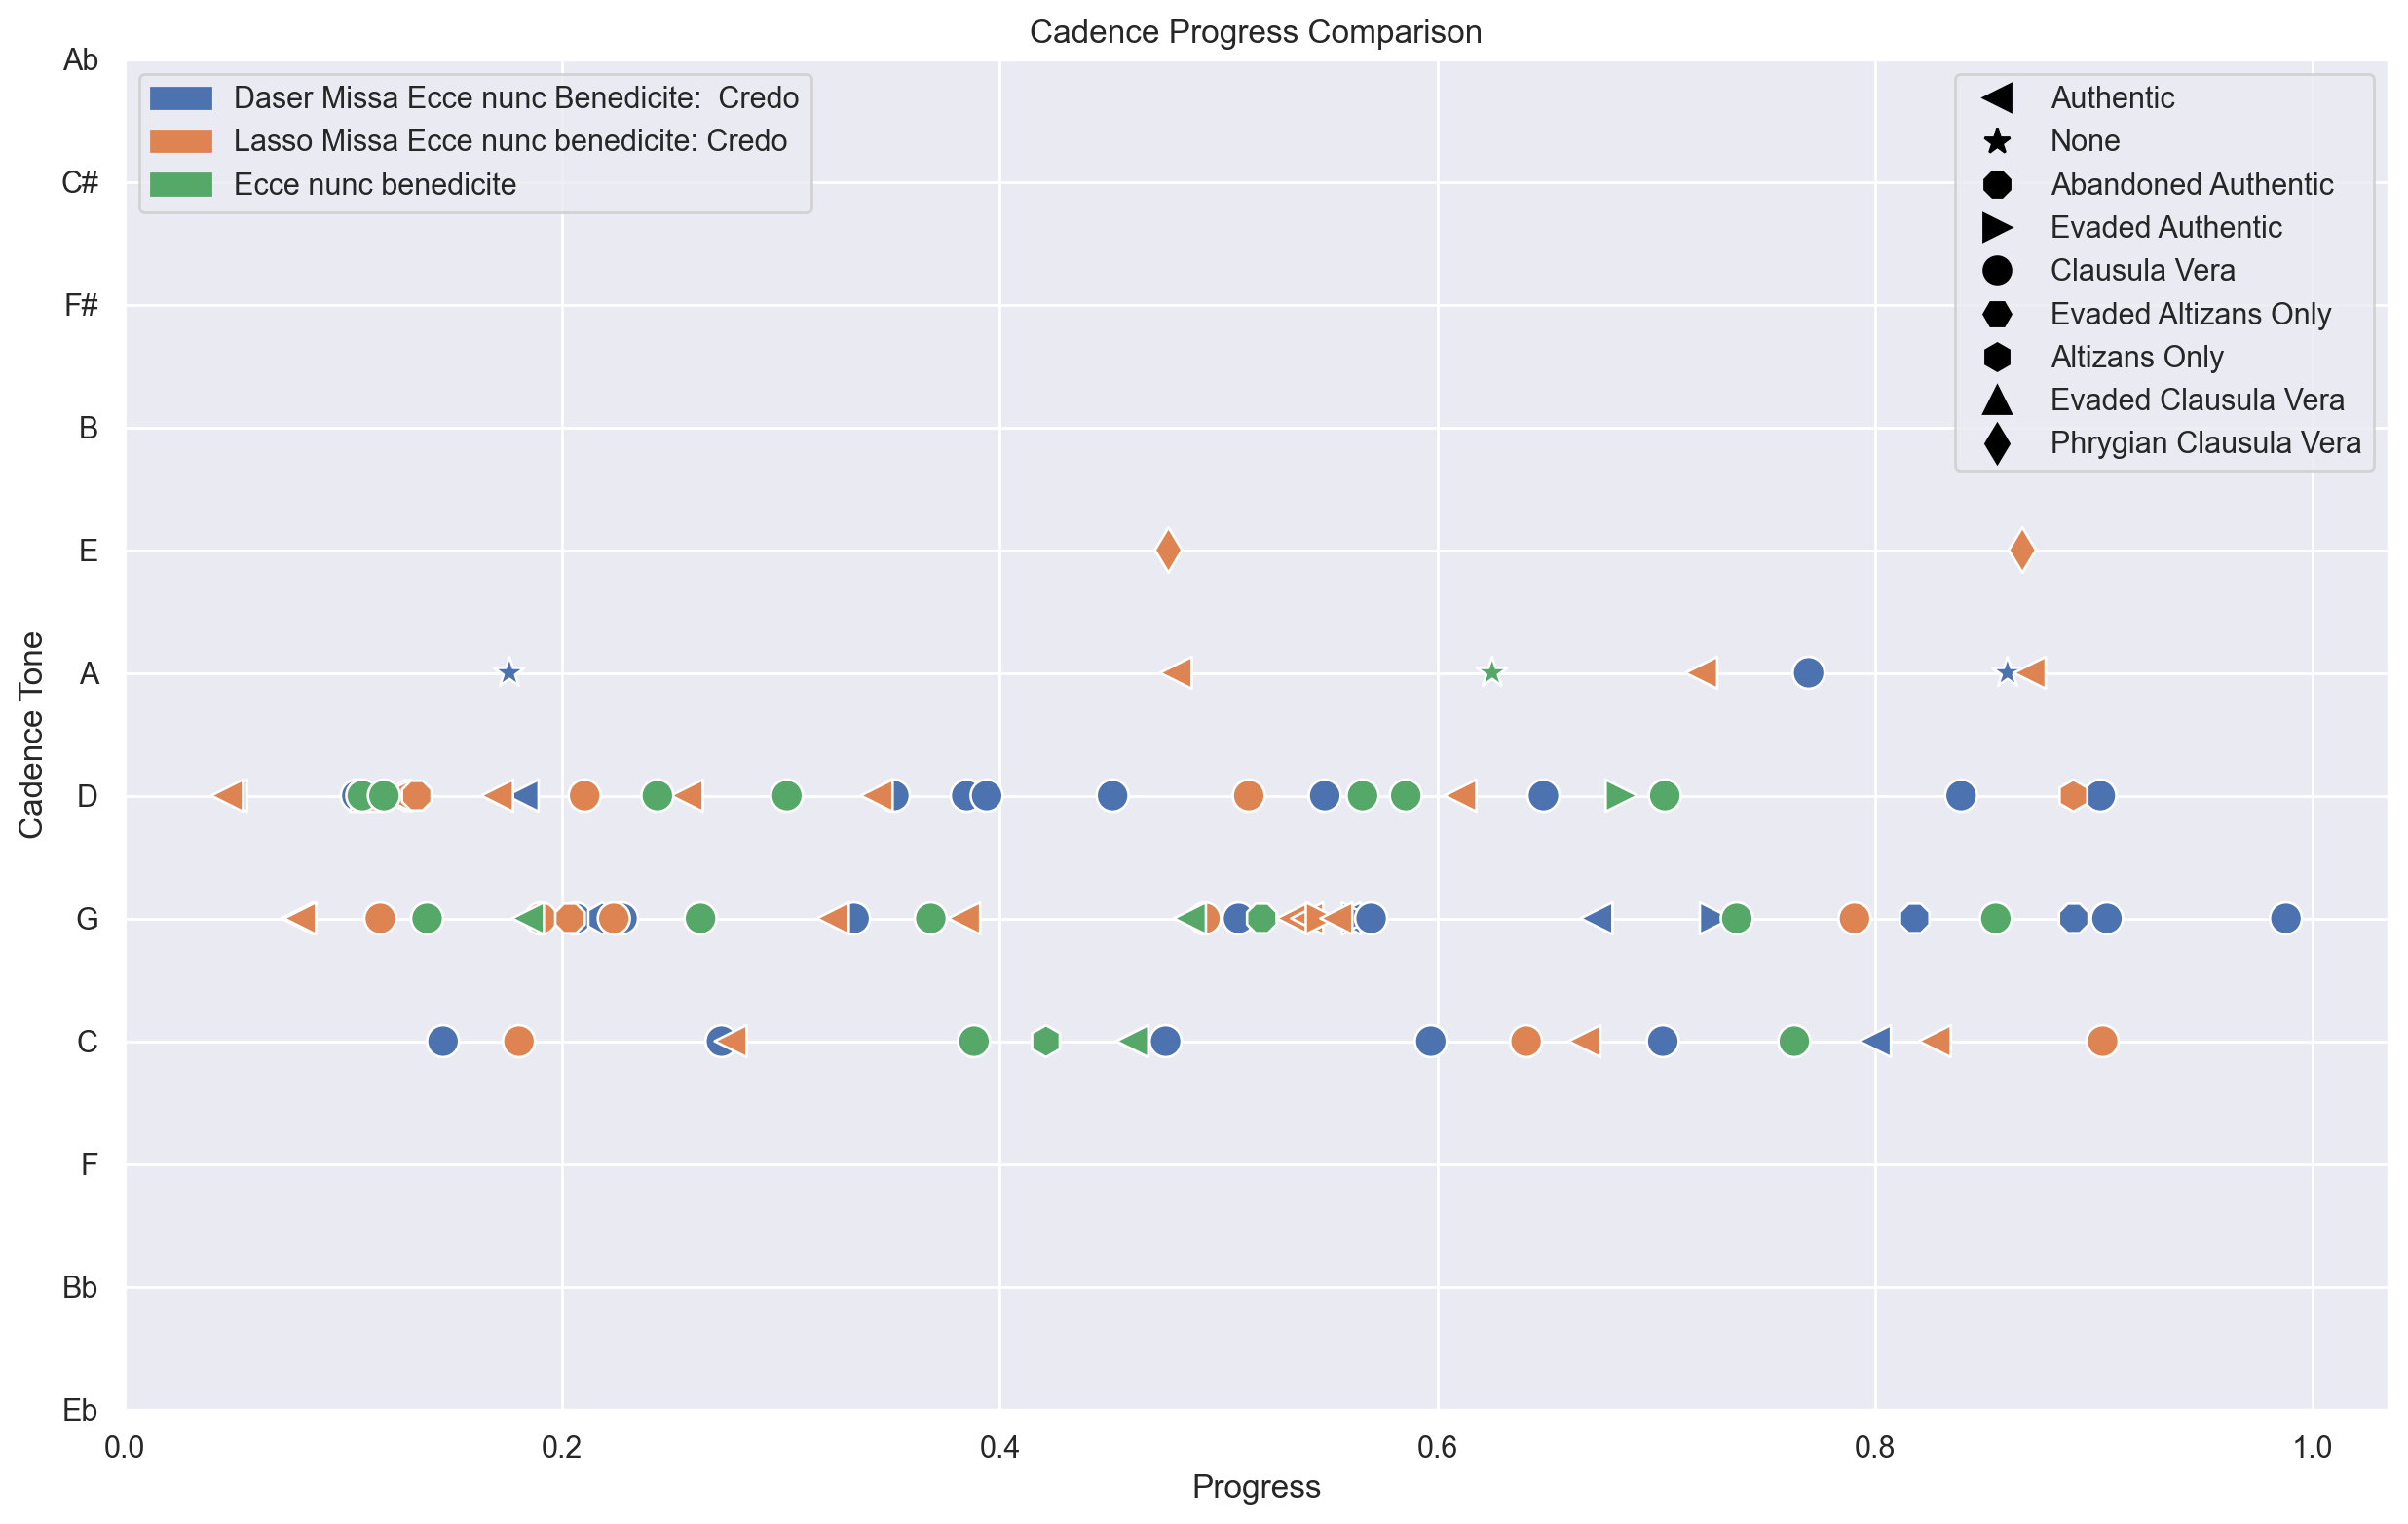

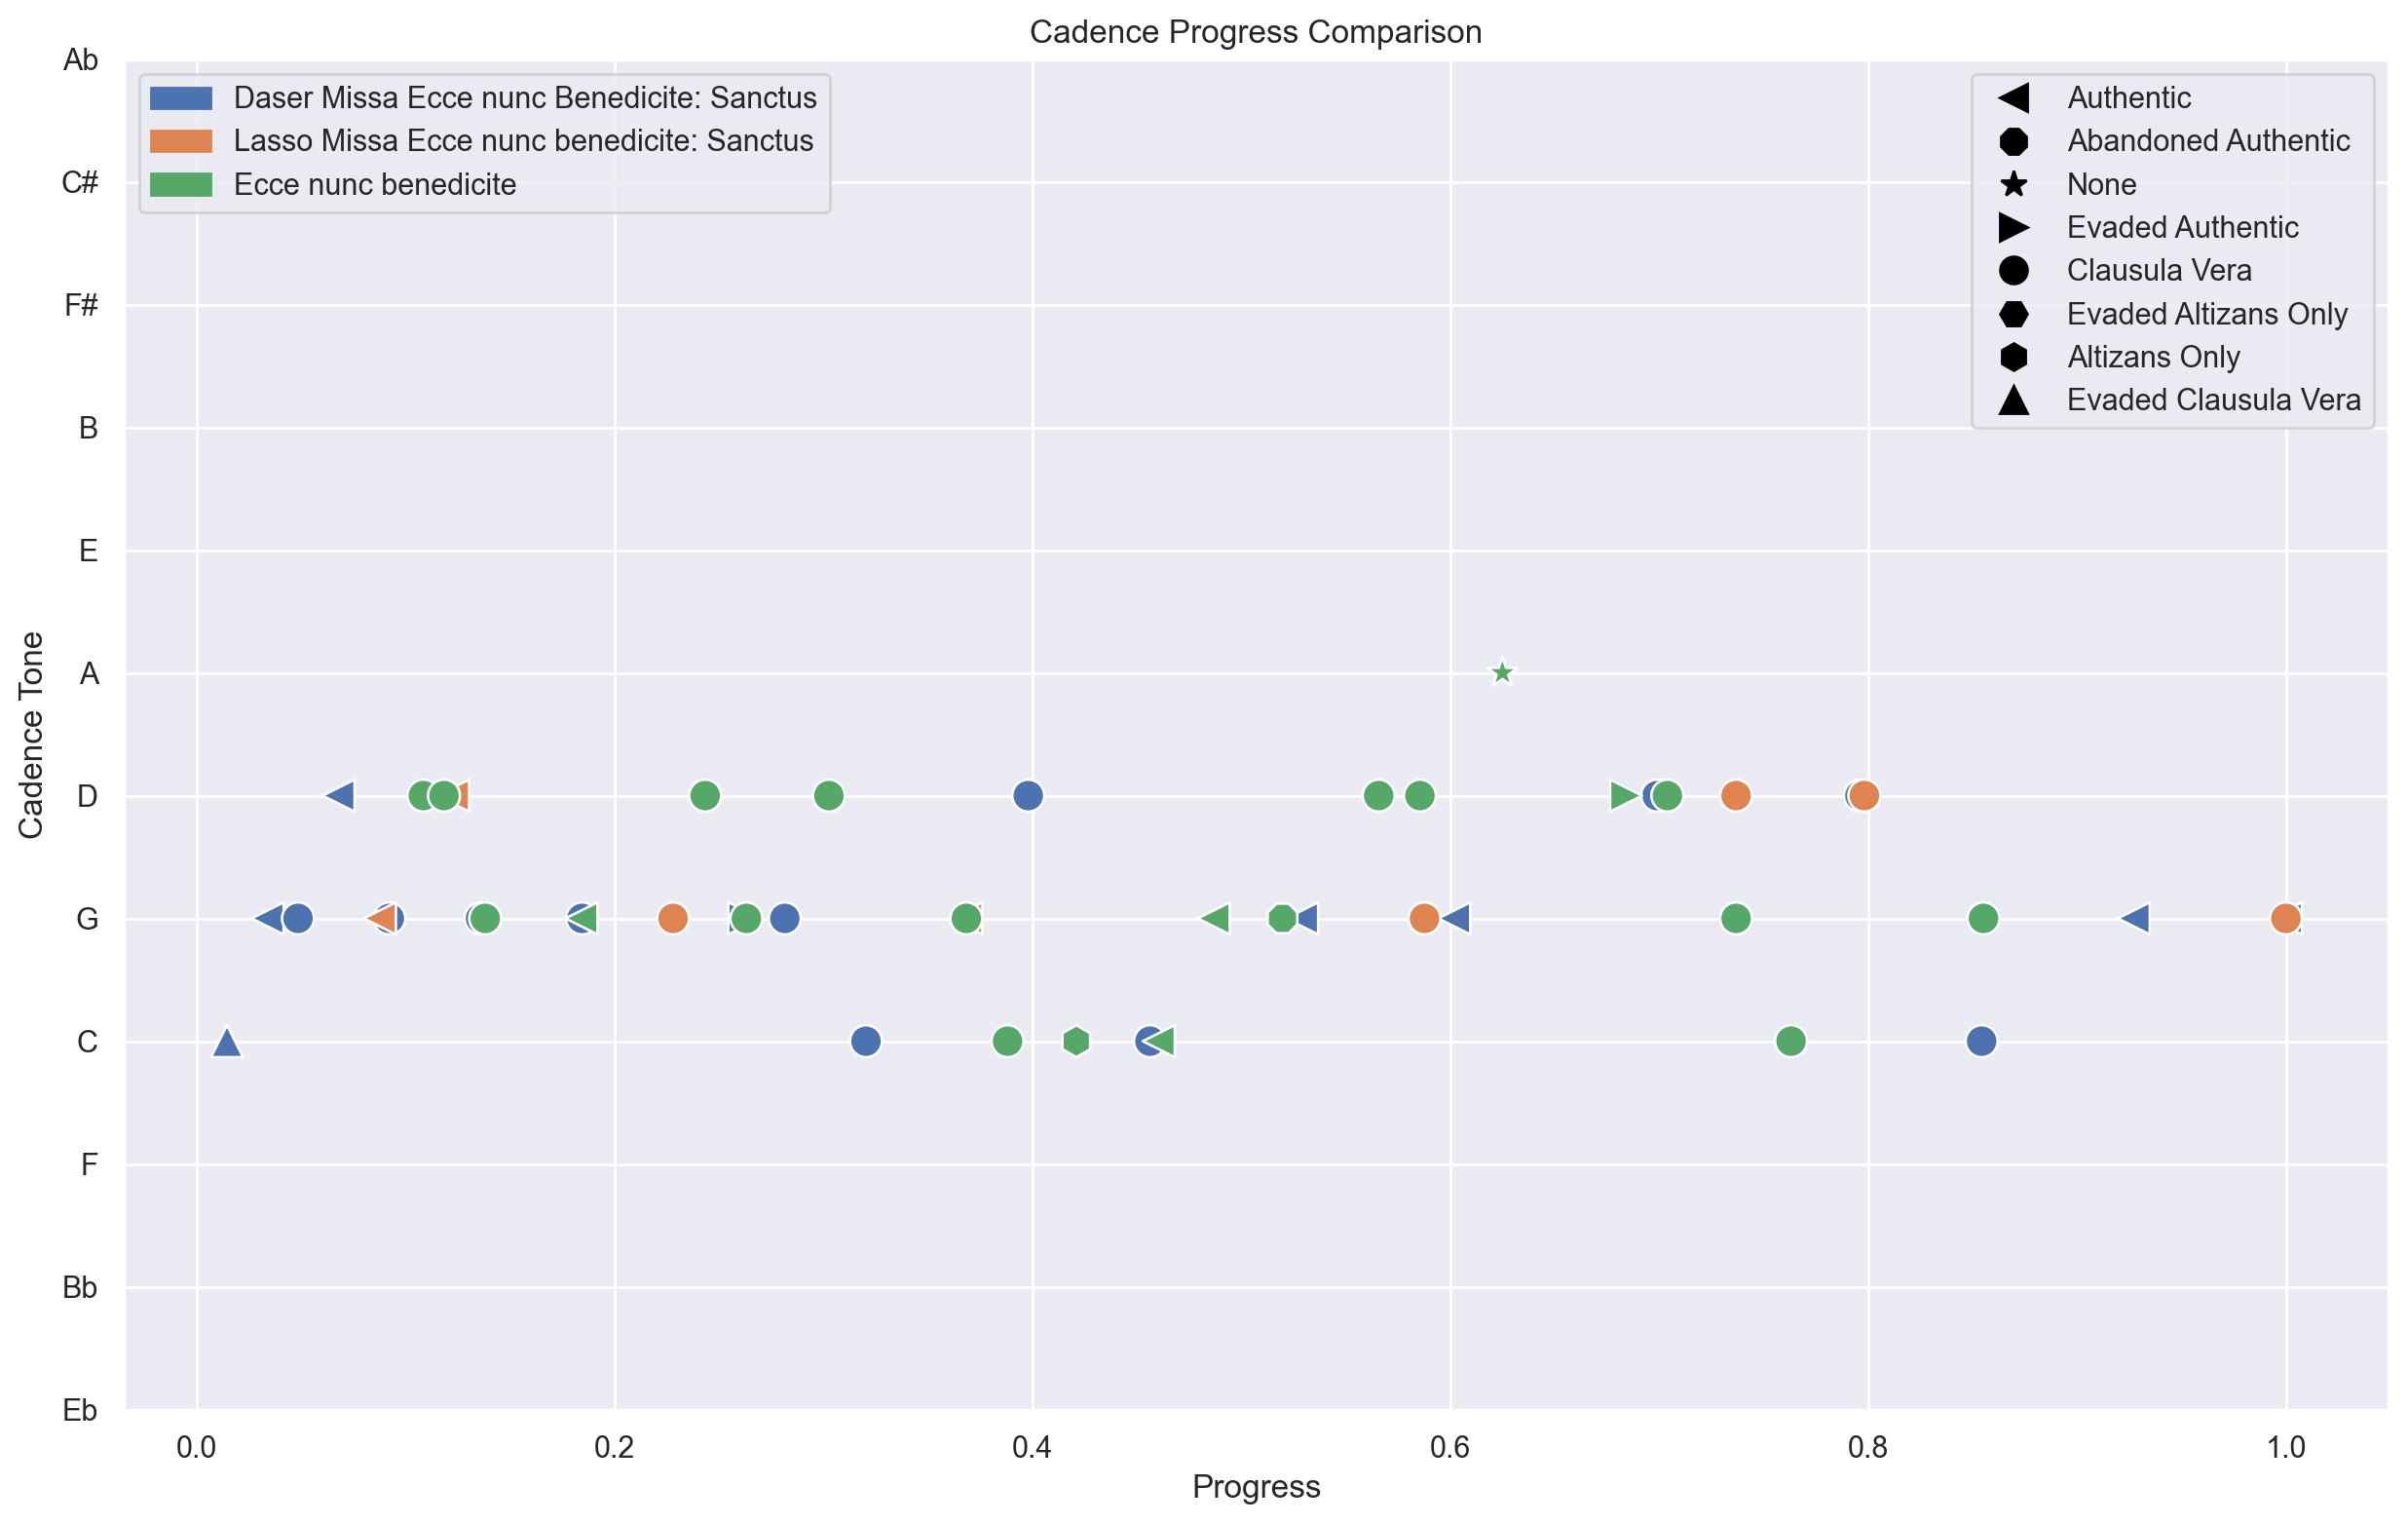

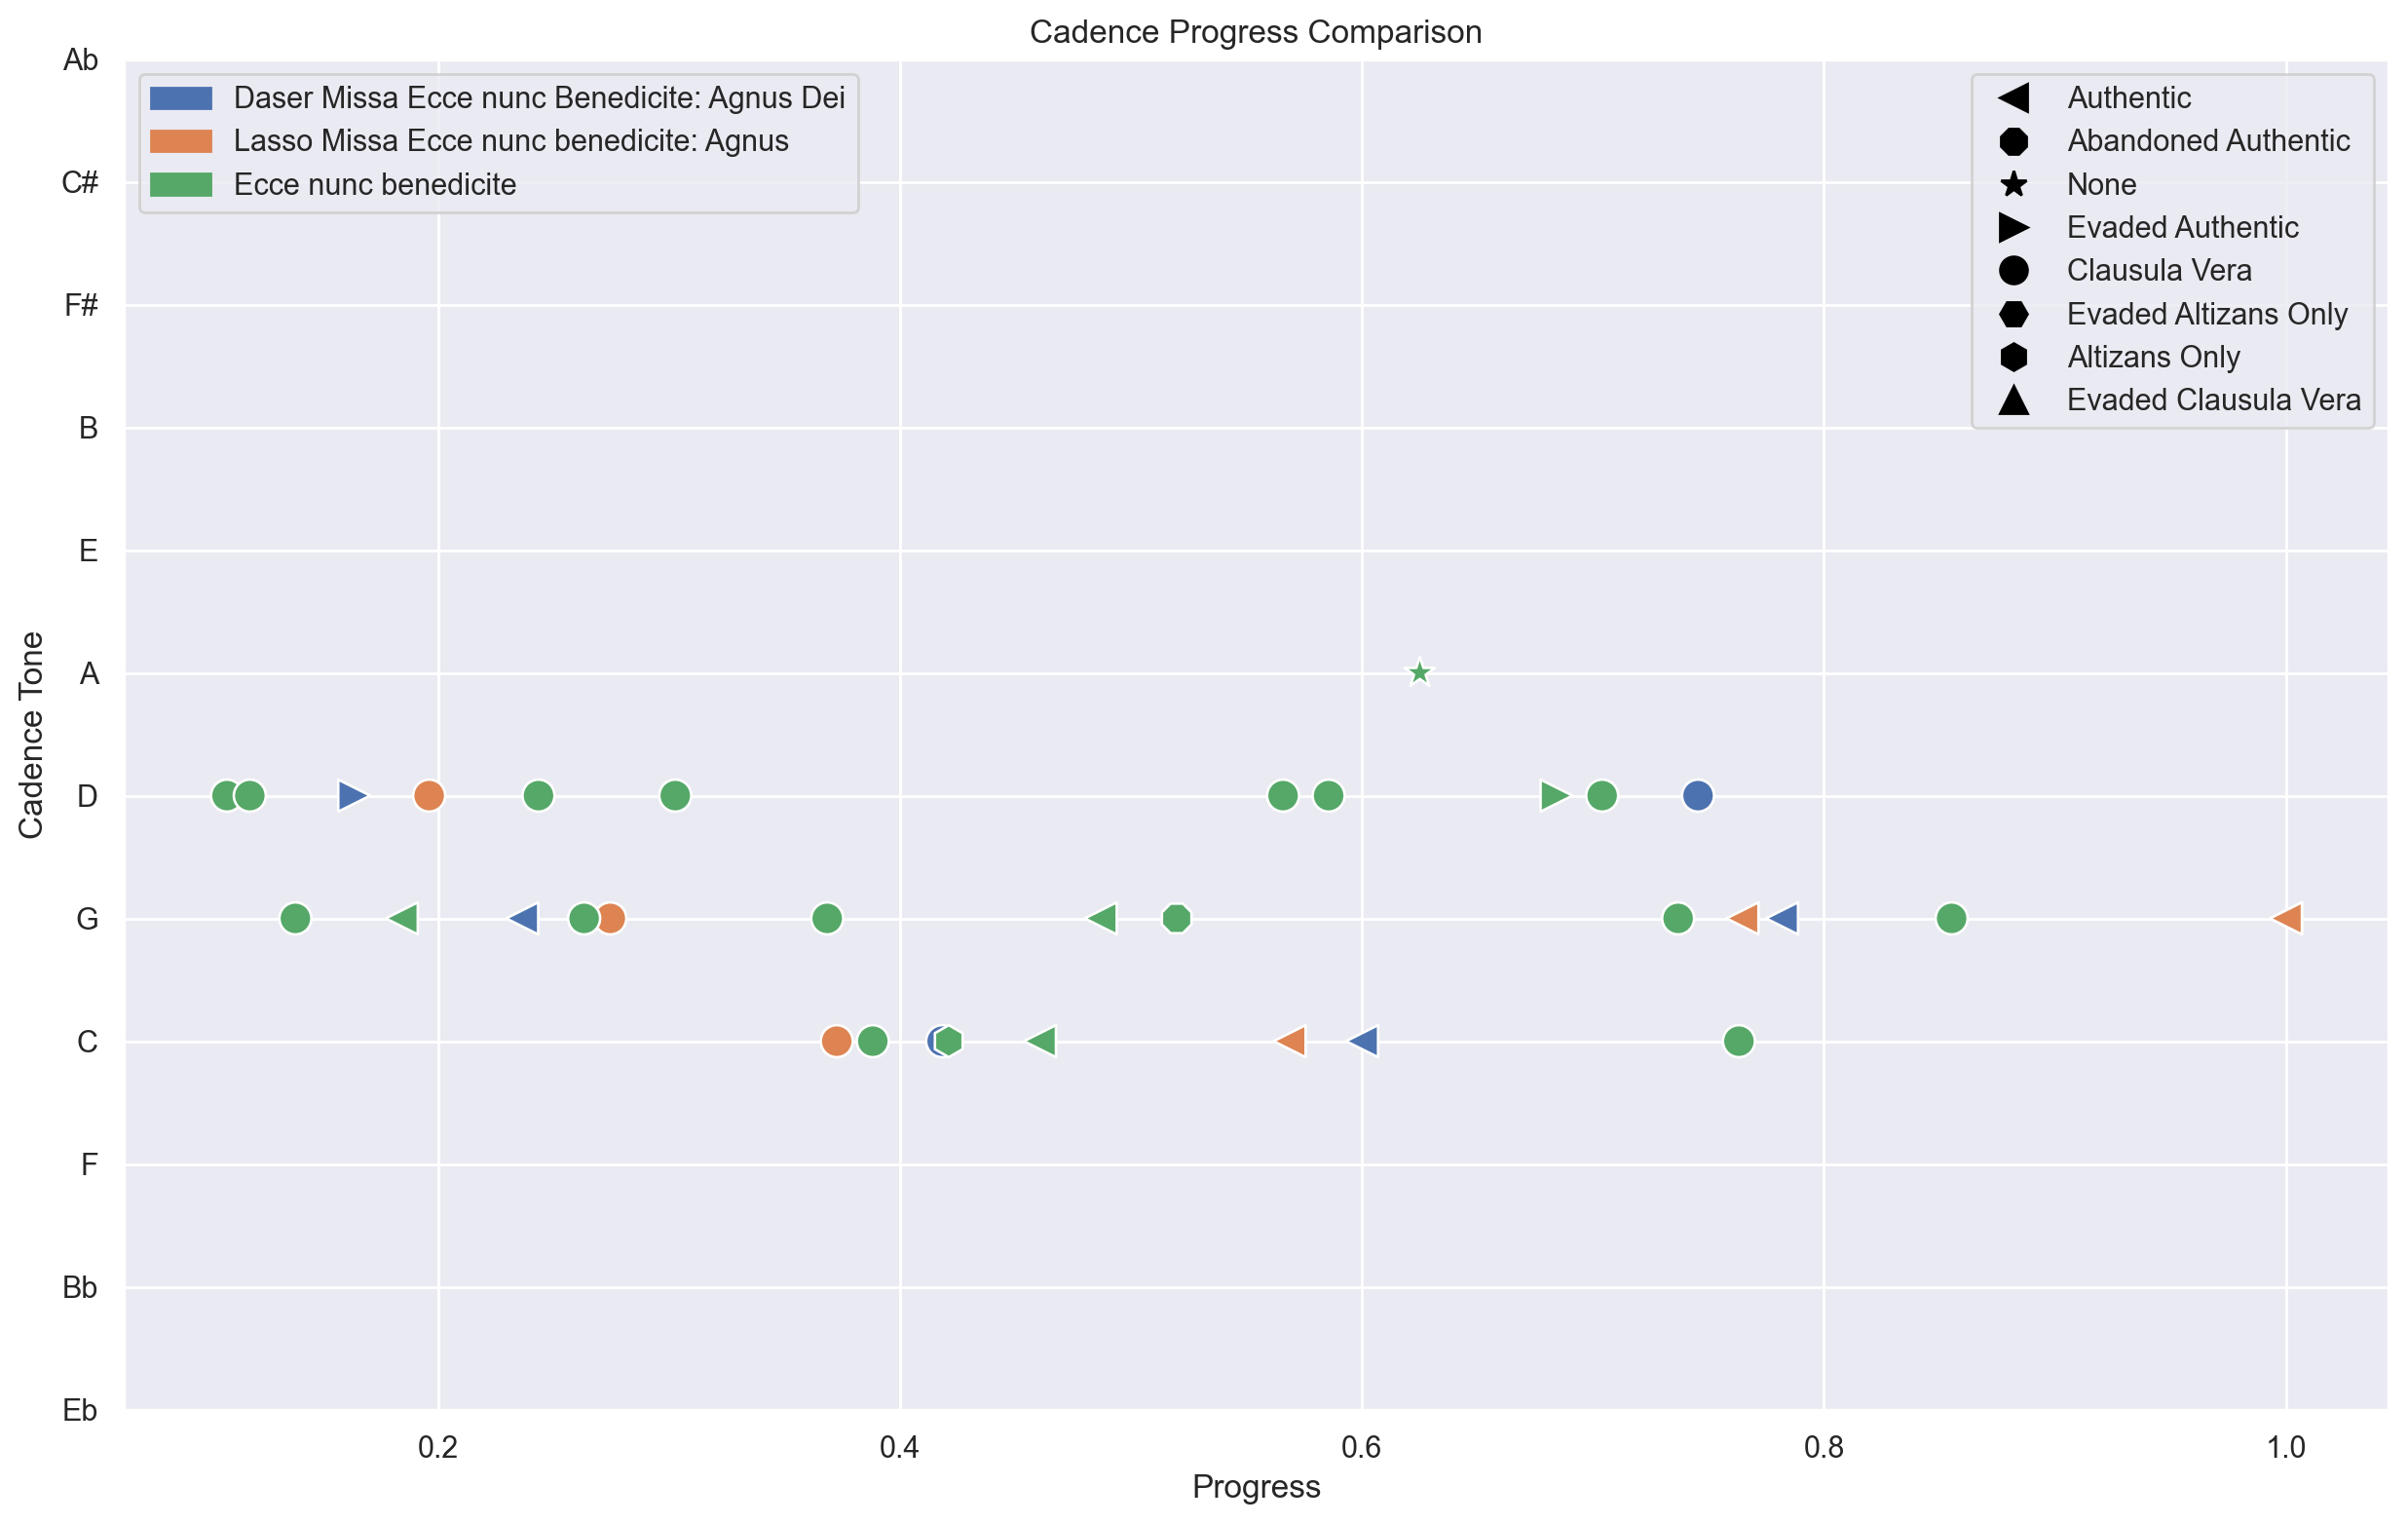

In [102]:
movement_ids = [1, 2, 3, 4, 5]

model =  'Music_Files/Daser_Motette_Ecce-nunc_E.mei'
file_paths = glob.glob('Music_Files/*.*')
# The string we're looking for
for movement_id in movement_ids:
    # Filter the list of file paths
    filtered_paths = [path for path in file_paths if str(movement_id) in path]
    filtered_paths.append(model)
    corpus = CorpusBase(filtered_paths)
    corpus.compareCadenceProgressPlots(includeType = True)


# Presentation Types

### One piece with Linked Examples

In [103]:
prefix = 'https://raw.githubusercontent.com/RichardFreedman/CRIM_Additions/main/Daser_Missa_Ecce_nunc/MEI/'
piece_id = 'Daser_Motette_Ecce-nunc_E.mei'

url = prefix + piece_id

# one piece with linked examples
model = importScore(url)
model.metadata
pt = model.presentationTypes(limit_to_entries = True,
                        head_flex=1,
                        body_flex = 0,
                        include_hidden_types = False,
                        combine_unisons = False,
                        melodic_ngram_length = 3)
pt = pt.reindex(columns=['Composer', 'Presentation_Type', 'Title', 'First_Offset', 'Measures_Beats', 'Melodic_Entry_Intervals', 'Offsets', 'Soggetti', 'Time_Entry_Intervals', 'Voices', 'Number_Entries', 'Flexed_Entries', 'Parallel_Entries', 'Parallel_Voice', 'Count_Non_Overlaps', 'Progress'])

# pt = pt.head()
model.linkExamples(df=pt, piece_url=url)

,Composer,Presentation_Type,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Progress
0,Ludwig Daser,"<a href=""https://eleon024.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fraw.githubusercontent.com%2FRichardFreedman%2FCRIM_Additions%2Fmain%2FDaser_Missa_Ecce_nunc%2FMEI%2FDaser_Motette_Ecce-nunc_E.mei&ema_expression=%2F15%2C16%2C17%2C19%2C20%2C21%2C22%2C24%2C25%2C26%2C27%2C28%2F1%2C1%2B2%2C2%2C3%2C3%2C4%2C4%2C1%2B2%2C1%2B2%2C3%2C3%2B4%2C4%2F%404.0-end%2C%401-3.0%2B%404.0-end%2C%401-3.0%2C%404.0-end%2C%401-3.0%2C%402.0-end%2C%401-1.0%2C%402.0-end%2B%404.0-end%2C%401-1.0%2B%401-2.0%2C%402.0-end%2C%401-1.0%2B%402.0-end%2C%401-1.0%2Fhighlight&measure_range=15-28&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA",Ecce nunc benedicite,118.0,"[15.0/4.0, 16.0/4.0, 19.0/4.0, 21.0/2.0, 24.0/2.0, 24.0/4.0, 26.0/2.0, 27.0/2.0]","[P-5, P-4, P-5, P12, P-5, P-4, P-5]","[118.0, 126.0, 150.0, 162.0, 186.0, 190.0, 202.0, 210.0]","[(-3, 2, 2)]","[8.0, 24.0, 12.0, 24.0, 4.0, 12.0, 8.0]","[Sopran, Alt, Tenor, Bass, Sopran, Alt, Tenor, Bass]",8,False,False,None,0,0.194079
1,Ludwig Daser,FUGA,Ecce nunc benedicite,230.0,"[29.0/4.0, 30.0/2.0, 31.0/2.0, 31.0/4.0, 33.0/4.0, 36.0/4.0]","[P12, M-9, M2, P4, P-11]","[230.0, 234.0, 242.0, 246.0, 262.0, 286.0]","[(2, -3, 2)]","[4.0, 8.0, 4.0, 16.0, 24.0]","[Alt, Sopran, Bass, Tenor, Sopran, Bass]",6,False,False,None,0,0.378289
2,Ludwig Daser,FUGA,Ecce nunc benedicite,244.0,"[31.0/3.0, 33.0/2.0]",[P-12],"[244.0, 258.0]","[(2, -3, 4)]",[14.0],"[Sopran, Bass]",2,False,False,None,0,0.401316
3,Ludwig Daser,FUGA,Ecce nunc benedicite,304.0,"[39.0/1.0, 39.0/4.0, 41.0/1.0, 43.0/4.0]","[P5, P-8, P-5]","[304.0, 310.0, 320.0, 342.0]","[(5, -2, 2)]","[6.0, 10.0, 22.0]","[Alt, Sopran, Tenor, Bass]",4,False,False,None,0,0.500000
4,Ludwig Daser,FUGA,Ecce nunc benedicite,390.0,"[49.0/4.0, 50.0/4.0]",[P8],"[390.0, 398.0]","[(1, 1, -2), (2, 1, -2)]",[8.0],"[Tenor, Sopran]",2,True,False,None,0,0.641447
5,Ludwig Daser,FUGA,Ecce nunc benedicite,412.0,"[52.0/3.0, 54.0/1.0]",[P12],"[412.0, 424.0]","[(2, -2, -2)]",[12.0],"[Bass, Sopran]",2,False,False,None,0,0.677632
6,Ludwig Daser,"<a href=""https://eleon024.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fraw.githubusercontent.com%2FRichardFreedman%2FCRIM_Additions%2Fmain%2FDaser_Missa_Ecce_nunc%2FMEI%2FDaser_Motette_Ecce-nunc_E.mei&ema_expression=%2F55%2C56%2C57%2C58%2C59%2C60%2C61%2C62%2C63%2F3%2C3%2C4%2C4%2C1%2C1%2B2%2C2%2C1%2C1%2F%402.0-end%2C%401-1.0%2C%402.0-end%2C%401-1.0%2C%404.0-end%2C%401-3.0%2B%404.0-end%2C%401-3.0%2C%404.0-end%2C%401-3.0%2Fhighlight&measure_range=55-63&observation=+FUGA"" rel=""noopener noreferrer"" target=""_blank"">FUGA",Ecce nunc benedicite,434.0,"[55.0/2.0, 57.0/2.0, 59.0/4.0, 60.0/4.0, 62.0/4.0]","[P-5, P12, P-5, P5]","[434.0, 450.0, 470.0, 478.0, 494.0]","[(-2, -2, -2)]","[16.0, 20.0, 8.0, 16.0]","[Tenor, Bass, Sopran, Alt, Sopran]",5,False,False,None,0,0.713816
7,Ludwig Daser,FUGA,Ecce nunc benedicite,466.0,"[59.0/2.0, 61.0/4.0, 62.0/2.0, 64.0/2.0]","[P-5, P5, P-4]","[466.0, 486.0, 490.0, 506.0]","[(-2, -2, -3)]","[20.0, 4.0, 16.0]","[Tenor, Bass, Tenor, Bass]",4,False,False,None,0,0.766447
8,Ludwig Daser,FUGA,Ecce nunc benedicite,526.0,"[66.0/4.0, 70.0/2.0]",[m-6],"[526.0, 554.0]","[(2, 1, 2)]",[28.0],"[Sopran, Tenor]",2,False,True,Tenor,1,0.865132


## Search Corpus for a Given Soggetto or P Type and Show Linked Examples

Here we make it possible to look for only a particular soggetto.  For instance:

```python
search_tuple = ('-2', '3', '-2')
```

In [104]:
search_tuple = ('-2', '3', '-2')

prefix = 'https://raw.githubusercontent.com/RichardFreedman/CRIM_Additions/main/Daser_Missa_Ecce_nunc/MEI/'

file_paths = glob.glob('Music_Files/*Ecce*')

dfs = []

for path in file_list:
    piece_id = os.path.basename(path) 
    url = prefix + piece_id  
    piece = importScore(url)
    pt=piece.presentationTypes(melodic_ngram_length=3,
                              limit_to_entries=True,
                              include_hidden_types=False,
                              head_flex=0)
    if len(pt) > 0:
        pt = pt.reindex(columns=['Composer', 'Presentation_Type', 'Title', 'First_Offset', 'Measures_Beats', 'Melodic_Entry_Intervals', 'Offsets', 'Soggetti', 'Time_Entry_Intervals', 'Voices', 'Number_Entries', 'Flexed_Entries', 'Parallel_Entries', 'Parallel_Voice', 'Count_Non_Overlaps', 'Progress'])

    
    # pt['Soggetti'] = pt['Soggetti'].apply(lambda x: str(x[0]) if x else '')
        pt['first_tuple'] = pt['Soggetti'].apply(lambda x: x[0] if x else None)
        
        # Filter the DataFrame
        filtered_df = pt[pt['Soggetti'].apply(lambda x: search_tuple in x)]
       
        if len(filtered_df) > 0:
        # if 'PEN' in pt['Presentation_Type'].values:
        
        # # filter for a given type
        #     # pt = pt.loc[pt['Presentation_Type'] == 'PEN']
            print(piece.metadata)
            piece.linkExamples(df=filtered_df, piece_url=url)


{'title': 'Missa Ecce nunc benedicite: Gloria', 'composer': 'Orlandus Lassus', 'date': None}


,Composer,Presentation_Type,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Progress,first_tuple
3,Orlandus Lassus,FUGA,Missa Ecce nunc benedicite: Gloria,74.0,"[10.0/2.0, 11.0/2.0]",[P5],"[74.0, 82.0]","[(-2, 3, -2)]",[8.0],"[Part-6, Part-4]",2,False,False,None,0,0.09893,"(-2, 3, -2)"


mei.base: WARNING: Importing <tie> without @startid and @endid is not yet supported.


{'title': 'Missa Ecce nunc benedicite: Credo', 'composer': 'Orlandus Lassus', 'date': None}


,Composer,Presentation_Type,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Progress,first_tuple
10,Orlandus Lassus,FUGA,Missa Ecce nunc benedicite: Credo,520.0,"[66.0/1.0, 66.0/2.0]",[M-6],"[520.0, 522.0]","[(-2, 3, -2)]",[2.0],"[Part-3, Part-4]",2,False,True,Part-6,0,0.433695,"(-2, 3, -2)"


{'title': 'Missa Ecce nunc benedicite: Sanctus', 'composer': 'Orlandus Lassus', 'date': None}


,Composer,Presentation_Type,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Count_Non_Overlaps,Progress,first_tuple
2,Orlandus Lassus,PEN,Missa Ecce nunc benedicite: Sanctus,184.0,"[24.0/1.0, 27.0/1.0, 30.0/1.0]","[P12, P-12]","[184.0, 208.0, 232.0]","[(-2, 3, -2)]","[24.0, 24.0]","[Part-6, Part-2, Part-6]",3,False,False,None,0,0.403509,"(-2, 3, -2)"


## Corpus P Types as Network

First we need to get all of the P Types in our corpus

In [105]:
file_list = glob.glob('Music_Files/*Ecce*')
file_list = sorted(file_list)
corpus = CorpusBase(file_list)

#select function.  remember to omit "()"
func = ImportedPiece.presentationTypes

#run function on each piece; be sure to include keyword arguments
list_of_dfs = corpus.batch(func = func, kwargs = {'head_flex': 0,
                                                  'melodic_ngram_length' : 3,
                                                  'limit_to_entries' : True,
                                                  'include_hidden_types' : True,
                                                  'head_flex' : 0}, metadata = True)

#concatenate the resulting dataframes into one
corpus_pts = pd.concat(list_of_dfs, ignore_index = False)
corpus_pts['Melodic_Entry_Intervals'] = corpus_pts['Melodic_Entry_Intervals'].apply(lambda x: '_'.join(x))


corpus_pts['Soggetti'] = corpus_pts['Soggetti'].apply(lambda x: '_'.join(map(str, x[0])))
corpus_pts['combined'] = corpus_pts['Soggetti'] + corpus_pts['Melodic_Entry_Intervals']
corpus_pts.head(5)

mei.base: WARNING: Importing <tie> without @startid and @endid is not yet supported.


,Composer,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Presentation_Type,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Progress,Date,combined
0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,96.0,"[13.0/1.0, 14.0/2.0, 17.0/2.0, 18.0/3.0]",P-5_P-4_P-5,"[96.0, 106.0, 130.0, 140.0]",-3_2_2,"[10.0, 24.0, 10.0]","[Discantus, Contratenor, Tenor, Bassus]",ID,4,False,False,None,0.342857,None,-3_2_2P-5_P-4_P-5
1,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,96.0,"[13.0/1.0, 14.0/2.0, 17.0/2.0]",P-5_P-4,"[96.0, 106.0, 130.0]",-3_2_2,"[10.0, 24.0]","[Discantus, Contratenor, Tenor]",FUGA,3,False,False,None,0.342857,None,-3_2_2P-5_P-4
2,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,96.0,"[13.0/1.0, 14.0/2.0, 18.0/3.0]",P-5_P-8,"[96.0, 106.0, 140.0]",-3_2_2,"[10.0, 34.0]","[Discantus, Contratenor, Bassus]",FUGA,3,False,False,None,0.342857,None,-3_2_2P-5_P-8
3,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,96.0,"[13.0/1.0, 17.0/2.0, 18.0/3.0]",P-8_P-5,"[96.0, 130.0, 140.0]",-3_2_2,"[34.0, 10.0]","[Discantus, Tenor, Bassus]",FUGA,3,False,False,None,0.342857,None,-3_2_2P-8_P-5
4,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,106.0,"[14.0/2.0, 17.0/2.0, 18.0/3.0]",P-4_P-5,"[106.0, 130.0, 140.0]",-3_2_2,"[24.0, 10.0]","[Contratenor, Tenor, Bassus]",FUGA,3,False,False,None,0.378571,None,-3_2_2P-4_P-5


## Network of P Types

And now create a network.  The nodes will represent the pieces.  The edges connect pieces that share the same p type.

In this case we are using the 'combined' p type (with information about the soggetto and the melodic intervals of imitation) as the basis of our edges:

These combined types look like this:

`-3_2_2P-4_P-5`

And now the groupby code:

```python
corpus_pts.groupby('combined')
```

In [106]:
# Create Edges Based on ptype
edges = []
for pt, group in corpus_pts.groupby('combined'):
    titles = group['Title'].unique()
    for i in range(len(titles)):
        for j in range(i+1, len(titles)):
            edges.append((titles[i], titles[j]))


G = nx.Graph()
G.add_nodes_from(corpus_pts['Title'])
G.add_edges_from(edges)
G = add_communities(G)

# set physics
cmap = Network(notebook=True,
                   width="1000",
                          height="750",
                          bgcolor="black", 
                          font_color="white")
cmap.set_options("""
{
"physics": {
"enabled": true,
"forceAtlas2Based": {
    "springLength": 1
},
"solver": "forceAtlas2Based"
}
}
""")

cmap.from_nx(G)

# return the network
cmap.show("final_topic_pairs.html")


## Sorting By the Soggetti (so that similar ones are adjacent!)


Now we sort the corpus p types so that they are organized by soggetto. This puts similar ptypes together for ease of review.

In [107]:
corpus_pts['First_Tuple'] = corpus_pts['Soggetti'].apply(lambda x: x[0] if x else None)

# Step 2: Sort the DataFrame based on the 'First_Tuple' column
df_sorted = corpus_pts.sort_values(by='First_Tuple')

# Optionally, you can drop the 'First_Tuple' column if it's no longer needed
# df_sorted.drop(columns=['First_Tuple'], inplace=True)
df_sorted.head()

,Composer,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Presentation_Type,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Progress,Date,combined,First_Tuple
0,Ludovi[cus] Daser,Daser Missa Ecce nunc Benedicite: Kyrie,96.0,"[13.0/1.0, 14.0/2.0, 17.0/2.0, 18.0/3.0]",P-5_P-4_P-5,"[96.0, 106.0, 130.0, 140.0]",-3_2_2,"[10.0, 24.0, 10.0]","[Discantus, Contratenor, Tenor, Bassus]",ID,4,False,False,None,0.342857,None,-3_2_2P-5_P-4_P-5,-
175,Ludwig Daser,Ecce nunc benedicite,162.0,"[21.0/2.0, 24.0/2.0, 24.0/4.0]",P12_P-5,"[162.0, 186.0, 190.0]",-3_2_2,"[24.0, 4.0]","[Bass, Sopran, Alt]",FUGA,3,False,False,None,0.266447,None,-3_2_2P12_P-5,-
174,Ludwig Daser,Ecce nunc benedicite,162.0,"[21.0/2.0, 24.0/2.0, 24.0/4.0, 26.0/2.0, 27.0/...",P12_P-5_P-4_P-5,"[162.0, 186.0, 190.0, 202.0, 210.0]",-3_2_2,"[24.0, 4.0, 12.0, 8.0]","[Bass, Sopran, Alt, Tenor, Bass]",FUGA,5,False,False,None,0.266447,None,-3_2_2P12_P-5_P-4_P-5,-
173,Ludwig Daser,Ecce nunc benedicite,162.0,"[21.0/2.0, 24.0/2.0, 26.0/2.0]",P12_P-8,"[162.0, 186.0, 202.0]",-3_2_2,"[24.0, 16.0]","[Bass, Sopran, Tenor]",FUGA,3,False,False,None,0.266447,None,-3_2_2P12_P-8,-
172,Ludwig Daser,Ecce nunc benedicite,162.0,"[21.0/2.0, 24.0/2.0, 26.0/2.0, 27.0/2.0]",P12_P-8_P-5,"[162.0, 186.0, 202.0, 210.0]",-3_2_2,"[24.0, 16.0, 8.0]","[Bass, Sopran, Tenor, Bass]",FUGA,4,False,False,None,0.266447,None,-3_2_2P12_P-8_P-5,-


## Homorhythm

Each passage of homorhythm is linked to a verovio example.

We can adjust ngram length and other features

```hr = piece.homorhythm(ngram_length =4)```

### For One Piece

In [108]:
# Annotated examples

prefix = 'https://raw.githubusercontent.com/RichardFreedman/CRIM_Additions/main/Daser_Missa_Ecce_nunc/MEI/'
piece_id = 'Daser_Missa_Ecce_nunc_01_E.mei'

url = prefix + piece_id
url

piece = importScore(url)
piece.metadata
hr = piece.homorhythm(ngram_length=4)
piece.linkExamples(df=hr, piece_url=url)

### For a Complete Corpus

In [109]:
# We also need to load the files from GIT, for the LinkExample function

prefix = 'https://raw.githubusercontent.com/RichardFreedman/CRIM_Additions/main/Daser_Missa_Ecce_nunc/MEI/'

dfs = []

for path in file_list:
    piece_id = os.path.basename(path) 
    url = prefix + piece_id  
    piece = importScore(url)
    hr=piece.homorhythm()
    # hr2 = hr
    
    if hr is not None:
        # print(piece_id)
        # piece.linkExamples(df=hr, piece_url=url)

    # filter for a given type or tone
        hr2 = hr[hr['active_voices'] >= 3.0]
        if len(hr2) >= 1.0:
        # if hr2 is not None:
            print(piece_id)
            piece.linkExamples(df=hr2, piece_url=url)
        else:
            print("Sorry, no HR with that number of active voices in " + piece_id)

Sorry, no HR with that number of active voices in Daser_Missa_Ecce_nunc_01_E.mei
Daser_Missa_Ecce_nunc_02_E.mei


Daser_Missa_Ecce_nunc_03_E.mei


Sorry, no HR with that number of active voices in Daser_Missa_Ecce_nunc_04_E.mei
Daser_Missa_Ecce_nunc_05_E.mei


,,,active_voices,number_dur_ngrams,hr_voices,Discantus,Alt,Tenor,Bassus,syllable_set,count_lyr_ngrams,active_syll_voices,voice_match,ngram_length,Progress
Measure,Beat,Offset,,,,,,,,,,,,,
17.0,1.0,128.0,3.0,1.0,"['Alt', 'Tenor', 'Bassus']",NaN,"(mun, di, mi, se)",NaN,"(mun, di, mi, se)","[(mun, di, mi, se), (mun, di, mi, se)]",1.0,2.0,False,4.0,0.581818


Daser_Motette_Ecce-nunc_E.mei


...

,,,active_voices,number_dur_ngrams,hr_voices,Part-1,Part-2,Part-3,Part-4,Part-5,Part-6,syllable_set,count_lyr_ngrams,active_syll_voices,voice_match,ngram_length,Progress
Measure,Beat,Offset,,,,,,,,,,,,,,,
67.0,2.0,530.0,4.0,1.0,"<a href=""https://eleon024.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fraw.githubusercontent.com%2FRichardFreedman%2FCRIM_Additions%2Fmain%2FDaser_Missa_Ecce_nunc%2FMEI%2FLassus_Missa_Ecce_02.mei&ema_expression=%2F67-68%2F3%2B2%2B4%2B1%2C3%2B2%2B4%2B1%2F%402.0-end%2B%402.0-end%2B%402.0-end%2B%402.0-end%2C%40start-1.0%2B%40start-1.0%2B%40start-1.0%2B%40start-1.0%2Fhighlight&measure_range=67-68&observation=+%5B%27Part-1%27%2C+%27Part-2%27%2C+%27Part-3%27%2C+%27Part-4%27%5D"" rel=""noopener noreferrer"" target=""_blank"">['Part-1', 'Part-2', 'Part-3', 'Part-4']","(ad, dex, teram, Pa)","(ad, dex, teram, Pa)","(ad, dex, teram, Pa)","(ad, dex, teram, Pa)",NaN,NaN,"[(ad, dex, teram, Pa), (ad, dex, teram, Pa), (ad, dex, teram, Pa), (ad, dex, teram, Pa)]",1.0,4.0,True,4.0,0.708556
77.0,2.0,610.0,3.0,1.0,"['Part-1', 'Part-5', 'Part-6']","(tu, so, lus, Al)",NaN,NaN,NaN,"(tu, so, lus, Al)","(tu, so, lus, Al)","[(tu, so, lus, Al), (tu, so, lus, Al), (tu, so, lus, Al)]",1.0,3.0,True,4.0,0.815508
87.0,4.0,694.0,4.0,1.0,"<a href=""https://eleon024.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fraw.githubusercontent.com%2FRichardFreedman%2FCRIM_Additions%2Fmain%2FDaser_Missa_Ecce_nunc%2FMEI%2FLassus_Missa_Ecce_02.mei&ema_expression=%2F87-88%2F6%2B3%2B5%2B4%2C6%2B3%2B5%2B4%2F%404.0-end%2B%404.0-end%2B%404.0-end%2B%404.0-end%2C%40start-3.0%2B%40start-3.0%2B%40start-3.0%2B%40start-3.0%2Fhighlight&measure_range=87-88&observation=+%5B%27Part-3%27%2C+%27Part-4%27%2C+%27Part-5%27%2C+%27Part-6%27%5D"" rel=""noopener noreferrer"" target=""_blank"">['Part-3', 'Part-4', 'Part-5', 'Part-6']",NaN,NaN,"(in, glo, ri, a)","(in, glo, ri, a)","(in, glo, ri, a)","(in, glo, ri, a)","[(in, glo, ri, a), (in, glo, ri, a), (in, glo, ri, a), (in, glo, ri, a)]",1.0,4.0,True,4.0,0.927807
89.0,2.0,706.0,4.0,1.0,"<a href=""https://eleon024.github.io/ema_react_app/?pieceURL=https%3A%2F%2Fraw.githubusercontent.com%2FRichardFreedman%2FCRIM_Additions%2Fmain%2FDaser_Missa_Ecce_nunc%2FMEI%2FLassus_Missa_Ecce_02.mei&ema_expression=%2F89-90%2F3%2B2%2B4%2B1%2C3%2B2%2B4%2B1%2F%402.0-end%2B%402.0-end%2B%402.0-end%2B%402.0-end%2C%40start-1.0%2B%40start-1.0%2B%40start-1.0%2B%40start-1.0%2Fhighlight&measure_range=89-90&observation=+%5B%27Part-1%27%2C+%27Part-2%27%2C+%27Part-3%27%2C+%27Part-4%27%5D"" rel=""noopener noreferrer"" target=""_blank"">['Part-1', 'Part-2', 'Part-3', 'Part-4']","(in, glo, ri, a)","(in, glo, ri, a)","(in, glo, ri, a)","(in, glo, ri, a)",NaN,NaN,"[(in, glo, ri, a), (in, glo, ri, a), (in, glo, ri, a), (in, glo, ri, a)]",1.0,4.0,True,4.0,0.943850


mei.base: WARNING: Importing <tie> without @startid and @endid is not yet supported.


Lassus_Missa_Ecce_03.mei


,,,active_voices,number_dur_ngrams,hr_voices,Part-1,Part-2,Part-3,Part-4,Part-5,Part-6,syllable_set,count_lyr_ngrams,active_syll_voices,voice_match,ngram_length,Progress
Measure,Beat,Offset,,,,,,,,,,,,,,,
8.0,4.5,63.0,3.0,1.0,"['Part-2', 'Part-3', 'Part-6']",NaN,"(si, bi, li, um)","(si, bi, li, um)",NaN,NaN,"(si, bi, li, um)","[(si, bi, li, um), (si, bi, li, um), (si, bi, li, um)]",1.0,3.0,True,4.0,0.052544


No HR passages found in Orlandus Lassus:Missa Ecce nunc benedicite: Sanctus
No HR passages found in Orlandus Lassus:Missa Ecce nunc benedicite: Agnus
